# Section 5.2 — Results of simulations

Regeneration of every figure and table of `results.tex`,
`\section{Results of simulations}` (`\label{sec:results-simulations}`, lines 222–652),
built **only** from the two CSVs in this folder:

| File | Rows | Formulation | Grain |
|---|---|---|---|
| `results_batch_dif_ren.csv` | 26 | **QHS** (`dif_ren`, branch `15min_different_ren`) | one row per solver run = one initial population $\lvert\Omega_0\rvert$ |
| `results_batch_same_ren.csv` | 55 | **HG** (`same_ren`, branch `15min_ren_same`) | same |
| `../Scenario tree results/scenario_tree_summary.csv` | 2 460 | both | one row per generated tree; supplies the tree-size axes of `tab:cliff` / `fig:sg-cliff` (section 0.2b) |

Both files map cleanly one-per-formulation — the `ren_type` and `branch` columns are
constant within each file and disagree between them. Granularity is **aggregate per run**:
one row per solved configuration, carrying model dimensions, timings, solver counters and
the objective broken down by market. There is no per-scenario or per-period content in
either file, which is what determines the reproducible / not-reproducible split below.

⚠️ **Read section 0.3 before using any timing output.** The QHS solve times in this CSV do
not match the ones published in the chapter; every other quantity does.

## 0. Setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

QHS_CSV = "results_batch_dif_ren.csv"
HG_CSV = "results_batch_same_ren.csv"

qhs_raw = pd.read_csv(QHS_CSV)
hg_raw = pd.read_csv(HG_CSV)

print("QHS", qhs_raw.shape, "| ren_type", qhs_raw["ren_type"].unique(),
      "| branch", qhs_raw["branch"].unique())
print("HG ", hg_raw.shape, "| ren_type", hg_raw["ren_type"].unique(),
      "| branch", hg_raw["branch"].unique())
qhs_raw.head(2)

QHS (26, 47) | ren_type <StringArray>
['dif_ren']
Length: 1, dtype: str | branch <StringArray>
['15min_different_ren']
Length: 1, dtype: str
HG  (55, 47) | ren_type <StringArray>
['same_ren']
Length: 1, dtype: str | branch <StringArray>
['15min_ren_same']
Length: 1, dtype: str


,ren_type,branch,num_scenarios_folder,scenario_dir,lane,pinned_cores,concurrency_lanes,threads_per_solve,pid,hostname,loadavg_1min_start,loadavg_1min_end,num_scenarios_original,num_scenarios_reduced,num_scenarios_in_model,preprocess_time_s,build_instance_time_s,solve_time_s,wall_time_total_s,solver_status,termination_condition,solver_message,solver_wallclock_time_s,num_variables,num_constraints,num_binary_vars,num_integer_vars,lower_bound,upper_bound,gurobi_nodes_explored,gurobi_simplex_iterations,gurobi_best_objective,gurobi_best_bound,gurobi_gap_pct,obj_fun,obj_DA_income,obj_RM_income,obj_IM_income,obj_IB_income,obj_IB_costs,obj_IB_net,obj_FD_costs,results_dir,solver_log_path,status,error,traceback
0,dif_ren,15min_different_ren,50,/users/delfos/aina/scentree-gen-remote/scentre...,0,"0,1,2,3",13,4,4002100,azathoth,0.008789,47.506836,50,46,46.0,0.524837,1.107776,405.701993,415.345799,ok,optimal,Model was solved to optimality (subject to tol...,<undefined>,123741.0,454089.0,13248.0,13248.0,-28014.412301,-27734.342778,1,200267,-28014.412301,-27734.342777,0.9997,-28014.412301,-38875.798822,5681.298794,5396.382582,490.333164,610.347405,-120.014241,96.280615,/users/delfos/aina/mmobec-pyomo/results/FTC_20...,/users/delfos/aina/mmobec-pyomo/results/FTC_20...,ok,NaN,NaN
1,dif_ren,15min_different_ren,60,/users/delfos/aina/scentree-gen-remote/scentre...,1,"4,5,6,7",13,4,4002103,azathoth,0.008789,40.572754,60,51,51.0,0.592994,1.223940,755.634209,766.288901,ok,optimal,Model was solved to optimality (subject to tol...,<undefined>,137191.0,534494.0,14688.0,14688.0,-26373.884074,-26110.452072,1,207221,-26373.884074,-26110.452072,0.9988,-26373.884074,-45442.736491,6093.082218,13251.907895,349.862570,531.287708,-181.425138,94.712558,/users/delfos/aina/mmobec-pyomo/results/FTC_20...,/users/delfos/aina/mmobec-pyomo/results/FTC_20...,ok,NaN,NaN


In [2]:
# ---------------------------------------------------------------------------
# Constants. Everything a downstream cell needs about the experimental design
# lives here.
# ---------------------------------------------------------------------------
LABEL = {"QHS": "QHS", "HG": "HG"}
ORDER = ["QHS", "HG"]

# Chapter colour scheme for the HG/QHS distinction. These two values are the
# only place the formulation colours are defined; every figure that separates
# the two formulations reads them from here.
COLORS = {"QHS": "#0B5395", "HG": "#7E9632"}
FIGSIZE_PAIR = (13, 4.4)
FIGSIZE_TRIO = (14, 4.4)

# --- figure export -----------------------------------------------------------
# Figures are written straight into the thesis tree, so that re-running this
# notebook end to end regenerates exactly the files results.tex includes.
FIGDIR = os.path.join("..", "..", "TFM_ASP", "figures")
FIG_DPI = 200


def save(fig, name):
    """Write `fig` to the thesis figures directory as <name>.png."""
    os.makedirs(FIGDIR, exist_ok=True)
    path = os.path.join(FIGDIR, f"{name}.png")
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"saved  {path}")
    return fig

# Range over which BOTH formulations converged: the chapter's "matched initial
# population" / secondary comparison range.
MATCHED_POP_MIN, MATCHED_POP_MAX = 50, 170

# Solver configuration (Table~\ref{tab:solver-config}, defined in methods.tex):
# relative MIP gap 1e-2, time limit 14400 s, 4 threads, presolve off, fixed seed.
MIP_GAP_TARGET_PCT = 1.0
TIME_LIMIT_S = 14_400

# Both formulations declare 288 binaries per retained scenario
# (96 quarter-hours x 3 binary families).
BINARIES_PER_SCENARIO = 288

# Objective components, in the order and with the sign convention of eq:dem-obj.
# NOTE ON SIGN: obj_DA_income is NEGATIVE (the community is a net buyer in the
# day-ahead market); obj_IB_net is negative (net imbalance cost). These signs are
# meaningful and are never abs()'d anywhere in this notebook.
OBJ_COMPONENTS = {
    "obj_DA_income": "Day-ahead",
    "obj_RM_income": "Reserve market",
    "obj_IM_income": "Intraday",
    "obj_IB_net": "Imbalance, net",
    "obj_FD_costs": "Flexible demand",
}


def tidy(df, label):
    """Normalise one batch CSV into the frame every cell below consumes."""
    out = df.copy()
    out["formulation"] = label
    out = out.rename(columns={
        "num_scenarios_folder": "pop_initial",     # |Omega_0|
        "num_scenarios_reduced": "pop_retained",   # |Omega|
        "num_constraints": "rows",
        "num_variables": "columns",
        "num_binary_vars": "binaries",
    })
    out["converged"] = out["status"] == "ok"
    return out.sort_values("pop_initial").reset_index(drop=True)


qhs = tidy(qhs_raw, "QHS")
hg = tidy(hg_raw, "HG")
runs = pd.concat([qhs, hg], ignore_index=True)

# Converged runs only -- every dimension/objective column is null for timeouts.
ok = runs[runs["converged"]].copy()

print(runs.groupby("formulation")["converged"].agg(["size", "sum"])
      .rename(columns={"size": "runs", "sum": "converged"}))

             runs  converged
formulation                 
HG             55         55
QHS            26         13


In [3]:
# --- matched retained counts, derived rather than hardcoded ------------------
# The chapter's primary comparison holds |Omega| fixed. Where a formulation
# reaches the same |Omega| from more than one |Omega_0|, tab:selected-sets takes
# the LARGER initial population; the same tie-break is applied here.
common_retained = sorted(
    set(ok.loc[ok.formulation == "QHS", "pop_retained"])
    & set(ok.loc[ok.formulation == "HG", "pop_retained"])
)

matched = {}
for count in common_retained:
    sel = {}
    for lab in ORDER:
        hits = ok[(ok.formulation == lab) & (ok.pop_retained == count)]
        sel[lab] = int(hits["pop_initial"].max())      # tie-break: larger |Omega_0|
    matched[count] = sel

MATCHED_COUNTS = list(matched)
print("retained counts reached by a converged run of BOTH formulations:", MATCHED_COUNTS)
for c, s in matched.items():
    print(f"  |Omega|={c:3d}  <-  QHS |Omega_0|={s['QHS']:3d}   HG |Omega_0|={s['HG']:3d}")


def at_matched(label, count, column):
    """Value of `column` for `label` at the matched configuration for `count`."""
    row = ok[(ok.formulation == label) & (ok.pop_initial == matched[count][label])]
    return row.iloc[0][column]

retained counts reached by a converged run of BOTH formulations: [55, 76, 108, 146]
  |Omega|= 55  <-  QHS |Omega_0|= 70   HG |Omega_0|=110
  |Omega|= 76  <-  QHS |Omega_0|= 90   HG |Omega_0|=220
  |Omega|=108  <-  QHS |Omega_0|=130   HG |Omega_0|=280
  |Omega|=146  <-  QHS |Omega_0|=170   HG |Omega_0|=560


### 0.2b — Scenario-tree metrics (cross-folder join)

`tab:cliff` and `fig:sg-cliff` locate the QHS tractability limit against **tree size** and
**effective scenario count**. Neither is a solver quantity, so neither is in this folder's
CSVs; both live in the scenario-generation corpus one folder over:

`../Scenario tree results/scenario_tree_summary.csv` — one row per (method, initial
population, day), 2 460 rows.

The chapter's figures are the **30-day means** of `num_nodes` and
`effective_num_scenarios` per initial population, not single-tree values: the published
8 404.6 nodes at $\lvert\Omega_0\rvert = 170$ is an average over the 30 generated trees,
whereas the solver solved only the day-1 tree. That distinction is preserved below — the
join is on initial population and the tree columns are labelled as 30-day averages.

In [4]:
# --- scenario-tree metrics, joined in from the scenario-generation corpus ----
TREE_SUMMARY_CSV = "../Scenario tree results/scenario_tree_summary.csv"
TREE_METHOD = {"dif_ren": "QHS", "same_ren": "HG"}   # as established in Section 5.1

tree_raw = pd.read_csv(TREE_SUMMARY_CSV)
tree_raw["formulation"] = tree_raw["method"].map(TREE_METHOD)

# The chapter reports 30-day AVERAGES of the tree metrics against each |Omega_0|.
tree_metrics = (tree_raw
                .groupby(["formulation", "sc_folder"])[
                    ["num_nodes", "effective_num_scenarios", "num_leaf_nodes"]]
                .mean()
                .rename(columns={"num_nodes": "tree_nodes_30d_mean",
                                 "effective_num_scenarios": "eff_scenarios_30d_mean",
                                 "num_leaf_nodes": "retained_30d_mean"})
                .reset_index()
                .rename(columns={"sc_folder": "pop_initial"}))

print(f"loaded {len(tree_raw)} trees over {tree_raw.day.nunique()} days; "
      f"averaged to {len(tree_metrics)} (formulation, |Omega_0|) rows")

# join onto every solver run, converged or not
runs_with_tree = runs.merge(tree_metrics, on=["formulation", "pop_initial"], how="left")
gap = runs_with_tree[runs_with_tree.tree_nodes_30d_mean.isna()]
print(f"solver runs with no matching tree row: {len(gap)}"
      + (f" -> {gap[['formulation', 'pop_initial']].to_dict('records')}" if len(gap) else ""))
tree_metrics.head(4)

loaded 2460 trees over 30 days; averaged to 82 (formulation, |Omega_0|) rows
solver runs with no matching tree row: 0


,formulation,pop_initial,tree_nodes_30d_mean,eff_scenarios_30d_mean,retained_30d_mean
0,HG,50,598.666667,15.225747,27.166667
1,HG,60,680.166667,16.965717,32.433333
2,HG,70,747.633333,16.175100,34.433333
3,HG,80,830.333333,16.743165,36.566667


### 0.3 — ⚠️ Provenance check: the QHS timings in this CSV are not the chapter's

Before anything is plotted, every quantity that the chapter publishes as a number is
compared against this CSV. The result splits cleanly:

- **Everything deterministic reproduces exactly** — objective values (all 26, both
  formulations), model dimensions (rows / columns / binaries at every matched count),
  the QHS timeout times, and every HG timing.
- **The QHS *converged* solve times do not** — all 13 differ, by up to 48%
  ($\lvert\Omega_0\rvert = 140$: 6 578.0 s here against 9 760.5 s in the chapter).

The pattern says `results_batch_dif_ren.csv` was **re-run** after the chapter was written:
a fixed seed reproduces the same optimum and the same model, but wall-clock time tracks
machine load, so only the timings moved. `results_batch_same_ren.csv` is the original.

**Consequence:** every timing-derived figure in this notebook (`tab:dimensions-matched`
solve-time columns, `tab:time-matched-original`, `fig:batch-time`, `fig:batch-efficiency`,
and the itemised timing statistics) renders the **new** numbers, which differ from the
published ones. The affected chapter claims are listed in the cell output below. Nothing
is silently reconciled — the CSV is reported as it stands.

In [5]:
# --- what the chapter publishes, for comparison ------------------------------
# Transcribed from results.tex tab:time-matched-original and tab:objective-matched.
CHAPTER_QHS_TIME = {50: 307.1, 60: 798.5, 70: 1006.9, 80: 929.1, 90: 891.8,
                    100: 2114.0, 110: 2725.0, 120: 4737.9, 130: 4642.1,
                    140: 9760.5, 150: 6713.4, 160: 7276.3, 170: 12098.9}
CHAPTER_HG_TIME = {50: 15.4, 60: 16.5, 70: 7.5, 80: 62.6, 90: 45.3, 100: 20.7,
                   110: 50.7, 120: 71.9, 130: 43.7, 140: 129.0, 150: 82.8,
                   160: 46.2, 170: 74.3}
CHAPTER_QHS_OBJ = {50: -28014.4, 60: -26373.9, 70: -27611.0, 80: -28684.2,
                   90: -27572.1, 100: -25736.9, 110: -29340.0, 120: -26271.7,
                   130: -27595.1, 140: -28158.1, 150: -28069.5, 160: -28543.1,
                   170: -26860.6}

def compare(label, published, column):
    got = (ok[ok.formulation == label].set_index("pop_initial")[column]
           .reindex(list(published)))
    return pd.DataFrame({"chapter": pd.Series(published), "csv": got.round(1),
                         "delta_%": ((got / pd.Series(published) - 1) * 100).round(1)})

provenance = pd.concat(
    {"QHS solve_time_s": compare("QHS", CHAPTER_QHS_TIME, "solve_time_s"),
     "HG solve_time_s": compare("HG", CHAPTER_HG_TIME, "solve_time_s"),
     "QHS obj_fun": compare("QHS", CHAPTER_QHS_OBJ, "obj_fun")},
    axis=1)

n_match = {k: int(np.isclose(provenance[(k, "chapter")], provenance[(k, "csv")],
                             rtol=1e-3).sum())
           for k in ["QHS solve_time_s", "HG solve_time_s", "QHS obj_fun"]}
print("values reproducing the chapter (of 13):", n_match)
provenance

values reproducing the chapter (of 13): {'QHS solve_time_s': 0, 'HG solve_time_s': 13, 'QHS obj_fun': 13}


QHS solve_time_s                  HG solve_time_s                QHS obj_fun                 
             chapter      csv delta_%         chapter    csv delta_%     chapter      csv delta_%
50             307.1    405.7    32.1            15.4   15.4     0.3    -28014.4 -28014.4     0.0
60             798.5    755.6    -5.4            16.5   16.5     0.2    -26373.9 -26373.9    -0.0
70            1006.9    836.5   -16.9             7.5    7.5    -0.3    -27611.0 -27611.0    -0.0
80             929.1    919.9    -1.0            62.6   62.6    -0.1    -28684.2 -28684.2     0.0
90             891.8    890.7    -0.1            45.3   45.3    -0.0    -27572.1 -27572.1    -0.0
100           2114.0   1959.5    -7.3            20.7   20.7    -0.0    -25736.9 -25736.9     0.0
110           2725.0   2966.5     8.9            50.7   50.7    -0.0    -29340.0 -29340.0    -0.0
120           4737.9   3638.9   -23.2            71.9   71.9    -0.1    -26271.7 -26271.7     0.0
130           4642.1   3376.5   -27.3            43.7   43.7     0.1    -27595.1 -27595.1     0.0
140           9760.5   6578.0   -32.6           129.0  129.0    -0.0    -28158.1 -28158.1     0.0
150           6713.4   6361.7    -5.2            82.8   82.8    -0.0    -28069.5 -28069.5     0.0
160           7276.3   7320.9     0.6            46.2   46.2    -0.1    -28543.1 -28543.1    -0.0
170          12098.9  11190.4    -7.5            74.3   74.3    -0.0    -26860.6 -26860.6     0.0

In [6]:
# --- headline timing claims recomputed on the current CSV --------------------
span = ok[ok.pop_initial.between(MATCHED_POP_MIN, MATCHED_POP_MAX)]
q_span = span[span.formulation == "QHS"].set_index("pop_initial")
h_span = span[span.formulation == "HG"].set_index("pop_initial")

matched_ratio = pd.Series(
    {c: at_matched("QHS", c, "solve_time_s") / at_matched("HG", c, "solve_time_s")
     for c in MATCHED_COUNTS})

affected = pd.DataFrame([
    ("time ratio at matched |Omega| , per count", "19.9 / 11.2 / 24.4 / 28.7",
     " / ".join(f"{v:.1f}" for v in matched_ratio)),
    ("time ratio at matched |Omega| , range & mean", "11.2-28.7, mean 21",
     f"{matched_ratio.min():.1f}-{matched_ratio.max():.1f}, mean {matched_ratio.mean():.1f}"),
    ("ratio at equal |Omega_0| , range & median", "14.9-162.8, median 75.7",
     f"{(q_span.solve_time_s/h_span.solve_time_s).min():.1f}-"
     f"{(q_span.solve_time_s/h_span.solve_time_s).max():.1f}, median "
     f"{(q_span.solve_time_s/h_span.solve_time_s).median():.1f}"),
    ("QHS solve time mean / median", "4154 / 2725 s",
     f"{q_span.solve_time_s.mean():.0f} / {q_span.solve_time_s.median():.0f} s"),
    ("QHS solve time range", "307.1-12098.9 s",
     f"{q_span.solve_time_s.min():.1f}-{q_span.solve_time_s.max():.1f} s"),
    ("QHS s per retained scenario / ratio to HG", "36.5 s, 40x",
     f"{(q_span.solve_time_s/q_span.pop_retained).mean():.1f} s, "
     f"{(q_span.solve_time_s/q_span.pop_retained).mean()/(h_span.solve_time_s/h_span.pop_retained).mean():.0f}x"),
    ("QHS time growth factor across the range", "39.4x",
     f"{q_span.solve_time_s.max()/q_span.solve_time_s.min():.1f}x"),
], columns=["claim", "chapter", "this CSV"]).set_index("claim")

print("Chapter claims affected by the QHS re-run:\n")
affected

Chapter claims affected by the QHS re-run:



,chapter,this CSV
claim,,
"time ratio at matched |Omega| , per count",19.9 / 11.2 / 24.4 / 28.7,16.5 / 11.2 / 17.8 / 26.5
"time ratio at matched |Omega| , range & mean","11.2-28.7, mean 21","11.2-26.5, mean 18.0"
"ratio at equal |Omega_0| , range & median","14.9-162.8, median 75.7","14.7-158.6, median 58.5"
QHS solve time mean / median,4154 / 2725 s,3631 / 2967 s
QHS solve time range,307.1-12098.9 s,405.7-11190.4 s
QHS s per retained scenario / ratio to HG,"36.5 s, 40x","32.0 s, 35x"
QHS time growth factor across the range,39.4x,27.6x


> **Note on one claim that was already wrong.** The chapter states the time ratio *"widens
> monotonically with problem size across the four matched points: $19.9\times$ at
> $\lvert\Omega\rvert = 55$, $11.2\times$ at $76$, $24.4\times$ at $108$ and $28.7\times$
> at $146$."* That series falls from 19.9 to 11.2 before rising, so it is not monotone in
> the chapter's own numbers, independently of the re-run. The new series (16.5, 11.2,
> 17.8, 26.5) has the same shape. The defensible claim is that the ratio grows from
> $\lvert\Omega\rvert = 76$ onward, or that the largest ratio occurs at the largest size.

---
# 5.2.1 — Computational cost of the two methodologies
`\label{subsec:results-computational-cost}`

## Table `tab:solver-config` — referenced, not defined in this section

The section opens by referring to the solver configuration table, but that table lives in
`methods.tex:434`, outside the section being rebuilt here. It is therefore **out of scope**
for this notebook.

Three of its fields are nonetheless corroborated by these CSVs and are shown below:
threads per solve, the host, and the time limit (recoverable from where the timeouts
cluster). Gurobi version, MIP gap tolerance, presolve setting and random seed are not
columns in the batch output.

In [7]:
config_evidence = pd.DataFrame({
    "threads_per_solve": runs.groupby("formulation")["threads_per_solve"].unique(),
    "concurrency_lanes": runs.groupby("formulation")["concurrency_lanes"].unique(),
    "hostname": runs.groupby("formulation")["hostname"].unique(),
    "timeout runs": runs[~runs.converged].groupby("formulation").size().reindex(ORDER).fillna(0),
})
timeouts = runs[~runs.converged]
print(f"time limit implied by the timeout cluster: "
      f"{timeouts.solve_time_s.min():.1f}-{timeouts.solve_time_s.max():.1f} s "
      f"(configured {TIME_LIMIT_S} s)")
config_evidence

time limit implied by the timeout cluster: 14495.6-14625.1 s (configured 14400 s)


,threads_per_solve,concurrency_lanes,hostname,timeout runs
formulation,,,,
HG,[4],"[1, 16]",[azathoth],0.0
QHS,[4],"[13, 16]",[azathoth],13.0


## Table `tab:dimensions-matched`
> *Model dimensions and solution time at equal retained-scenario count. Columns and
> binaries are identical between formulations at every matched count; rows differ only
> through the nonanticipativity system.*

**Reproducible** (with the timing caveat of 0.3). Rows = `num_constraints`,
Columns = `num_variables`, Binaries = `num_binary_vars`, Solve time = `solve_time_s`,
each taken at the matched configuration for $\lvert\Omega\rvert \in \{55, 76, 108, 146\}$.
The dimension columns reproduce the published table exactly; the QHS solve-time column
does not.

In [8]:
# --- computation -------------------------------------------------------------
dimensions_matched = pd.DataFrame(
    {c: {(metric_label, lab): at_matched(lab, c, col)
         for col, metric_label in [("rows", "Rows"), ("columns", "Columns"),
                                   ("binaries", "Binaries"), ("solve_time_s", "Solve time [s]")]
         for lab in ORDER}
     for c in MATCHED_COUNTS}).T
dimensions_matched.index.name = "|Omega|"
dimensions_matched.columns = pd.MultiIndex.from_tuples(dimensions_matched.columns)

dimensions_matched.round(1)

Rows              Columns           Binaries          Solve time [s]       
               QHS         HG       QHS        HG      QHS       HG            QHS     HG
|Omega|                                                                                  
55        589346.0   555322.0  147951.0  148006.0  15840.0  15840.0          836.5   50.7
76        937437.0   870124.0  204441.0  204517.0  21888.0  21888.0          890.7   79.7
108      1696651.0  1629304.0  290521.0  290629.0  31104.0  31104.0         3376.5  190.0
146      2904695.0  2755220.0  392741.0  392887.0  42048.0  42048.0        11190.4  421.8

In [9]:
# --- the derived statements made in the paragraph after the table ------------
dims = pd.DataFrame({
    "binaries / |Omega|": {c: at_matched("QHS", c, "binaries") / c for c in MATCHED_COUNTS},
    "columns QHS/|Omega|": {c: at_matched("QHS", c, "columns") / c for c in MATCHED_COUNTS},
    "columns HG/|Omega|": {c: at_matched("HG", c, "columns") / c for c in MATCHED_COUNTS},
    "column ratio HG/QHS": {c: at_matched("HG", c, "columns") / at_matched("QHS", c, "columns")
                            for c in MATCHED_COUNTS},
    "row ratio QHS/HG": {c: at_matched("QHS", c, "rows") / at_matched("HG", c, "rows")
                         for c in MATCHED_COUNTS},
})
print(f"binaries per retained scenario: {dims['binaries / |Omega|'].unique()} "
      f"(declared {BINARIES_PER_SCENARIO})")
print(f"columns per retained scenario: QHS {dims['columns QHS/|Omega|'].mean():.0f}, "
      f"HG {dims['columns HG/|Omega|'].mean():.0f}; "
      f"HG carries more at every count: {bool((dims['column ratio HG/QHS'] > 1).all())}")
print(f"row ratio QHS/HG: {dims['row ratio QHS/HG'].min():.3f}-"
      f"{dims['row ratio QHS/HG'].max():.3f}, mean {dims['row ratio QHS/HG'].mean():.3f}")
print(f"\nsolve-time ratio QHS/HG at matched count: "
      f"{', '.join(f'{v:.1f}x' for v in matched_ratio)}")
dims.round(3)

binaries per retained scenario: [288.] (declared 288)
columns per retained scenario: QHS 2690, HG 2691; HG carries more at every count: True
row ratio QHS/HG: 1.041-1.077, mean 1.059

solve-time ratio QHS/HG at matched count: 16.5x, 11.2x, 17.8x, 26.5x


,binaries / |Omega|,columns QHS/|Omega|,columns HG/|Omega|,column ratio HG/QHS,row ratio QHS/HG
55,288.0,2690.018,2691.018,1.0,1.061
76,288.0,2690.013,2691.013,1.0,1.077
108,288.0,2690.009,2691.009,1.0,1.041
146,288.0,2690.007,2691.007,1.0,1.054


## The itemised quantities reported in the text
> *"The following quantities are reported as a function of the number of retained
> scenarios, for both formulations: **Execution time**, **Number of iterations**,
> **Memory consumption**, **Certified optimality gap**, **Numerical feasibility**."*

This bulleted list is a results table in prose form, so it gets the same treatment.
The chapter marks four of the five as `[MISSING]`.

### 🔎 Two of those `[MISSING]` items are in fact present in these CSVs

| Item | Chapter says | Actually in the CSV? |
|---|---|---|
| Execution time breakdown | reported | ✅ `preprocess_time_s`, `build_instance_time_s`, `solve_time_s`, `wall_time_total_s` |
| Root-relaxation vs B&B split | *"Not recorded in results_batch_{same,dif}_ren.csv"* | ❌ correct — not present |
| **B&B nodes explored** | *"not recorded in the batch CSVs"* | ✅ **`gurobi_nodes_explored` is present** |
| **Simplex/barrier iterations** | *"not recorded in the batch CSVs"* | ✅ **`gurobi_simplex_iterations` is present** |
| Peak memory | *"not recorded"* | ❌ correct — not present |
| **Numeric final MIP gap** | *"not recorded numerically… what is recorded is the terminal status"* | ✅ **`gurobi_gap_pct` is present** |
| Max constraint violation / NAC post-checks | *"not exported"* | ❌ correct — not present |

The gap register in `results.tex` is out of date on three counts. Note what
`gurobi_nodes_explored` actually says, though — see the cell output.

In [10]:
# --- execution-time decomposition -------------------------------------------
TIME_PARTS = ["preprocess_time_s", "build_instance_time_s", "solve_time_s"]

timing = ok.groupby("formulation")[TIME_PARTS + ["wall_time_total_s"]].agg(["min", "max"])
solve_share = (ok["solve_time_s"] / ok["wall_time_total_s"] * 100)
share = ok.assign(solve_share_pct=solve_share).groupby("formulation")["solve_share_pct"].agg(["min", "max"])

print("solve time as % of wall-clock:")
print(share.round(1).to_string())
print()
timing.round(2)

solve time as % of wall-clock:
              min   max
formulation            
HG           52.0  99.0
QHS          97.7  99.6



preprocess_time_s       build_instance_time_s       solve_time_s           wall_time_total_s          
                          min   max                   min   max          min       max               min       max
formulation                                                                                                       
HG                       0.41  4.17                  0.23  1.81         7.47   6464.94             14.37   6528.85
QHS                      0.52  1.69                  0.50  1.31       405.70  11190.36            415.35  11231.58

In [11]:
# --- solver counters the chapter reports as unavailable ----------------------
counters = ok.groupby("formulation")[
    ["gurobi_nodes_explored", "gurobi_simplex_iterations", "gurobi_gap_pct"]
].agg(["min", "median", "max"])

print("gurobi_nodes_explored distinct values:",
      {lab: sorted(ok.loc[ok.formulation == lab, "gurobi_nodes_explored"].unique())
       for lab in ORDER})
print("-> every run reports exactly 1 node, i.e. the root node. The B&B tree is not")
print("   explored because the 1% gap is met at the root; this column therefore does")
print("   NOT provide the branch-and-bound depth the chapter wanted, though it is")
print("   itself the evidence for Remark rem:root-relaxation.")
print()
print(f"final MIP gap: every converged run is at or below the {MIP_GAP_TARGET_PCT}% target: "
      f"{bool((ok['gurobi_gap_pct'] <= MIP_GAP_TARGET_PCT).all())}")
print()
print("but the two formulations stop for DIFFERENT reasons:")
for lab in ORDER:
    g = ok.loc[ok.formulation == lab, "gurobi_gap_pct"]
    print(f"  {lab:4s} gap {g.min():.4f}-{g.max():.4f}%  "
          f"({int((g > 0.9).sum())}/{len(g)} runs above 0.9%)")
counters.round(4)

gurobi_nodes_explored distinct values: {'QHS': [np.int64(1)], 'HG': [np.int64(1)]}
-> every run reports exactly 1 node, i.e. the root node. The B&B tree is not
   explored because the 1% gap is met at the root; this column therefore does
   NOT provide the branch-and-bound depth the chapter wanted, though it is
   itself the evidence for Remark rem:root-relaxation.

final MIP gap: every converged run is at or below the 1.0% target: True

but the two formulations stop for DIFFERENT reasons:
  QHS  gap 0.9402-0.9998%  (13/13 runs above 0.9%)
  HG   gap 0.0000-0.1184%  (0/55 runs above 0.9%)


gurobi_nodes_explored            gurobi_simplex_iterations                    gurobi_gap_pct                
                              min median max                       min    median      max            min  median     max
formulation                                                                                                             
HG                              1    1.0   1                     36696  235544.0   468695         0.0000  0.0000  0.1184
QHS                             1    1.0   1                    200267  719811.0  1389282         0.9402  0.9988  0.9998

> **The gap column says more than "≤ 1%".** QHS terminates in a narrow band just under the
> tolerance (0.9402–0.9998%) — every run stops *because it hit the 1% tolerance*. HG
> terminates at 0.0000–0.1184%, with most runs at exactly zero — it stops because the
> problem is *solved*. So the chapter's statement that both "certify a gap at or below 1%"
> is true but flattens a real asymmetry: the QHS objectives carry up to 1% of residual
> optimality gap, the HG ones essentially none. This matters for
> `tab:objective-matched`, where the QHS–HG difference is 23.6–34.6% — an order of
> magnitude larger than the gap, so the ordering conclusion survives — but it should be
> stated rather than left implicit.

> **What `gurobi_nodes_explored` reveals.** It is exactly `1` for all 68 converged runs, in
> both formulations. The solver meets the 1% gap at the root node and never branches. That
> makes the *"root-relaxation vs branch-and-bound split"* the chapter asks for degenerate —
> essentially all solve time **is** root time — which is direct support for
> `Remark~\ref{rem:root-relaxation}`, the very thing the chapter says it cannot evidence.
> The gap between the two formulations is therefore a gap in root-relaxation cost, and the
> `gurobi_simplex_iterations` column (below) quantifies it.

In [12]:
# --- iterations, the quantity that separates the two at the root -------------
iterations = pd.DataFrame({
    "simplex iterations": ok.groupby("formulation")["gurobi_simplex_iterations"].median(),
    "iterations per retained scenario": (
        ok.assign(x=ok.gurobi_simplex_iterations / ok.pop_retained)
        .groupby("formulation")["x"].median()),
    "seconds per 1000 iterations": (
        ok.assign(x=ok.solve_time_s / ok.gurobi_simplex_iterations * 1000)
        .groupby("formulation")["x"].median()),
})
iterations.round(2)

,simplex iterations,iterations per retained scenario,seconds per 1000 iterations
formulation,,,
HG,235544.0,2091.04,1.00
QHS,719811.0,7029.81,4.12


In [13]:
# --- certified optimality gap: the convergence census the chapter reports -----
census = runs.groupby(["formulation", "status"]).size().rename("runs").reset_index()
print(f"total configurations attempted: {len(runs)}")
print(f"converged: {int(runs.converged.sum())}   did not: {int((~runs.converged).sum())}")
print(f"all non-converged runs are QHS: "
      f"{bool((runs[~runs.converged].formulation == 'QHS').all())}")
print(f"their solve times cluster at {timeouts.solve_time_s.min():.1f}"
      f"-{timeouts.solve_time_s.max():.1f} s against a {TIME_LIMIT_S} s limit")
census

total configurations attempted: 81
converged: 68   did not: 13
all non-converged runs are QHS: True
their solve times cluster at 14495.6-14625.1 s against a 14400 s limit


,formulation,status,runs
0,HG,ok,55
1,QHS,ok,13
2,QHS,timeout_no_solution,13


**Memory consumption** and **numerical feasibility** (maximum constraint violation, the
post-solution nonanticipativity checks) are genuinely absent: no column in either CSV
records them. They are covered in the gap list of the final summary.

## Table `tab:time-matched-original`
> *Solution time at equal initial population, over the range in which both formulations
> converge.*

**Reproducible** (with the timing caveat of 0.3). `solve_time_s` for both formulations over
$\lvert\Omega_0\rvert \in [50, 170]$, plus their ratio. The HG column reproduces the
published table exactly; the QHS column and hence every ratio do not.

In [14]:
# --- computation -------------------------------------------------------------
time_matched = pd.DataFrame({
    "QHS [s]": q_span["solve_time_s"],
    "HG [s]": h_span["solve_time_s"],
})
time_matched["Ratio"] = time_matched["QHS [s]"] / time_matched["HG [s]"]
time_matched.index.name = "|Omega_0|"

# the size statements made in the paragraph after the table
size_ratio = pd.DataFrame({
    "rows QHS/HG": q_span["rows"] / h_span["rows"],
    "columns QHS/HG": q_span["columns"] / h_span["columns"],
    "binaries QHS/HG": q_span["binaries"] / h_span["binaries"],
})
print("over |Omega_0| in [50,170], QHS carries:")
for c in size_ratio:
    print(f"  {c}: mean {size_ratio[c].mean():.2f} (range {size_ratio[c].min():.2f}"
          f"-{size_ratio[c].max():.2f})")
time_matched.round(1)

over |Omega_0| in [50,170], QHS carries:
  rows QHS/HG: mean 3.01 (range 1.70-4.83)
  columns QHS/HG: mean 1.89 (range 1.30-2.75)
  binaries QHS/HG: mean 1.89 (range 1.30-2.75)


,QHS [s],HG [s],Ratio
|Omega_0|,,,
50,405.7,15.4,26.3
60,755.6,16.5,45.7
70,836.5,7.5,111.9
80,919.9,62.6,14.7
90,890.7,45.3,19.7
100,1959.5,20.7,94.7
110,2966.5,50.7,58.5
120,3638.9,71.9,50.6
130,3376.5,43.7,77.2


## Figure `fig:batch-time` — `figures/batch_time_vs_count`
> *Solution time against initial population (left) and against retained population
> (right), for both formulations.*

**Reproducible** (with the timing caveat of 0.3). Timeouts are drawn as open markers at the
time limit so the QHS cliff is visible rather than silently dropped.

saved  ..\..\TFM_ASP\figures\batch_time_vs_count.png


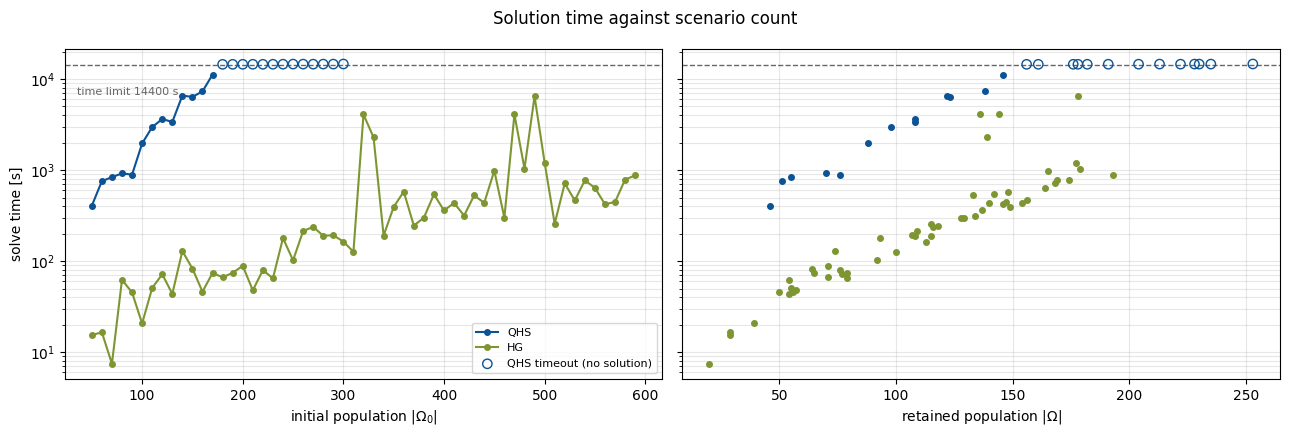

In [15]:
# --- computation -------------------------------------------------------------
# Converged runs carry a real solve time; timeouts are plotted separately at the
# limit, since their recorded time is the limit plus overshoot, not a solve cost.
converged_runs = runs[runs.converged]
timeout_runs = runs[~runs.converged]

# --- plotting ----------------------------------------------------------------
LOG_TIME_AXIS = True        # times span 7.5 s to 12 000 s

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharey=True)
for ax, xcol, xlabel in [
        (axes[0], "pop_initial", r"initial population $|\Omega_0|$"),
        (axes[1], "pop_retained", r"retained population $|\Omega|$")]:
    for lab in ORDER:
        sub = converged_runs[converged_runs.formulation == lab].sort_values(xcol)
        # |Omega| is NOT monotone in |Omega_0|: several initial populations reduce to
        # the same or a smaller retained count. Joining those points with a line would
        # imply an ordering the data does not have, so the retained-count panel is
        # drawn as markers only.
        joined = xcol == "pop_initial"
        ax.plot(sub[xcol], sub["solve_time_s"], marker="o", ms=4,
                lw=1.5 if joined else 0, ls="-" if joined else "none",
                color=COLORS[lab], label=lab)
    to = timeout_runs.sort_values(xcol)
    if len(to):
        ax.scatter(to[xcol], to["solve_time_s"], facecolors="none",
                   edgecolors=COLORS["QHS"], s=45, zorder=3,
                   label="QHS timeout (no solution)")
    ax.axhline(TIME_LIMIT_S, color="0.4", ls="--", lw=1)
    ax.set_xlabel(xlabel)
    if LOG_TIME_AXIS:
        ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")

axes[0].set_ylabel("solve time [s]")
axes[0].annotate(f"time limit {TIME_LIMIT_S} s", (0.02, 0.86),
                 xycoords="axes fraction", fontsize=8, color="0.4")
axes[0].legend(fontsize=8)
fig.suptitle("Solution time against scenario count")
fig.tight_layout()
save(fig, "batch_time_vs_count")
plt.show()

## Figure `fig:batch-size` — `figures/batch_model_size`
> *Model dimensions against scenario count for both formulations.*

**Reproducible.** Rows, columns and binaries against retained population. Dimensions are
recorded only for converged runs (they are null for the 13 QHS timeouts), so the QHS
series stops at $\lvert\Omega\rvert = 146$.

saved  ..\..\TFM_ASP\figures\batch_model_size.png


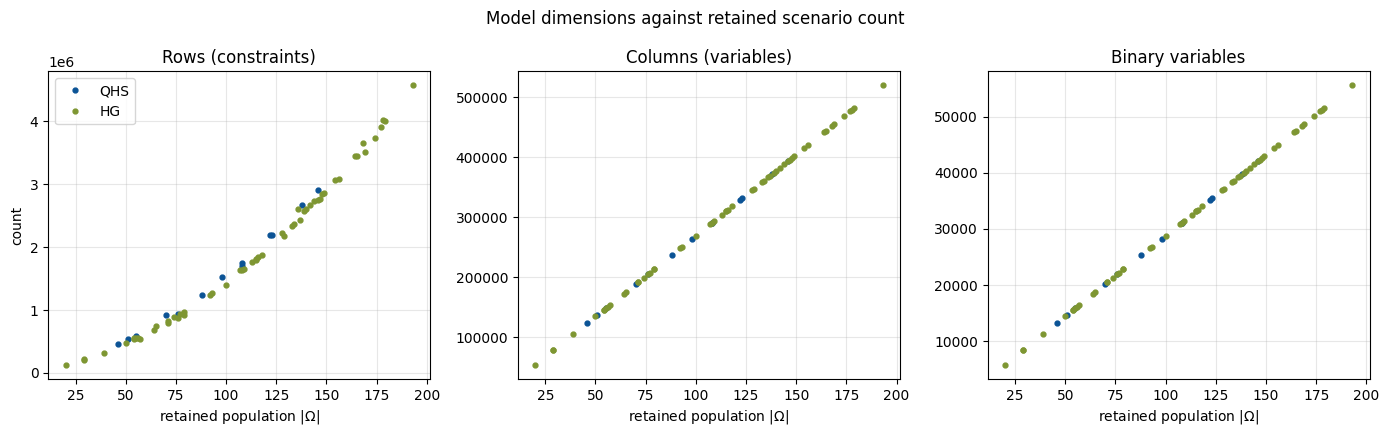

In [16]:
# --- computation -------------------------------------------------------------
SIZE_PANELS = [("rows", "Rows (constraints)"),
               ("columns", "Columns (variables)"),
               ("binaries", "Binary variables")]

# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_TRIO)
for ax, (col, title) in zip(axes, SIZE_PANELS):
    for lab in ORDER:
        sub = converged_runs[converged_runs.formulation == lab].sort_values("pop_retained")
        # markers only: |Omega| is not monotone in |Omega_0| (see fig:batch-time)
        ax.plot(sub["pop_retained"], sub[col], marker="o", ms=3.5, lw=0, ls="none",
                color=COLORS[lab], label=lab)
    ax.set_title(title)
    ax.set_xlabel(r"retained population $|\Omega|$")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("count")
axes[0].legend()
fig.suptitle("Model dimensions against retained scenario count")
fig.tight_layout()
save(fig, "batch_model_size")
plt.show()

## Figure `fig:batch-efficiency` — `figures/batch_reduction_efficiency`
> *Reduction ratio and solution time per retained scenario, by formulation.*

**Reproducible** (with the timing caveat of 0.3). Reduction ratio
$\rho = \lvert\Omega\rvert / \lvert\Omega_0\rvert$ from the two population columns; time
per retained scenario is `solve_time_s / pop_retained`.

saved  ..\..\TFM_ASP\figures\batch_reduction_efficiency.png


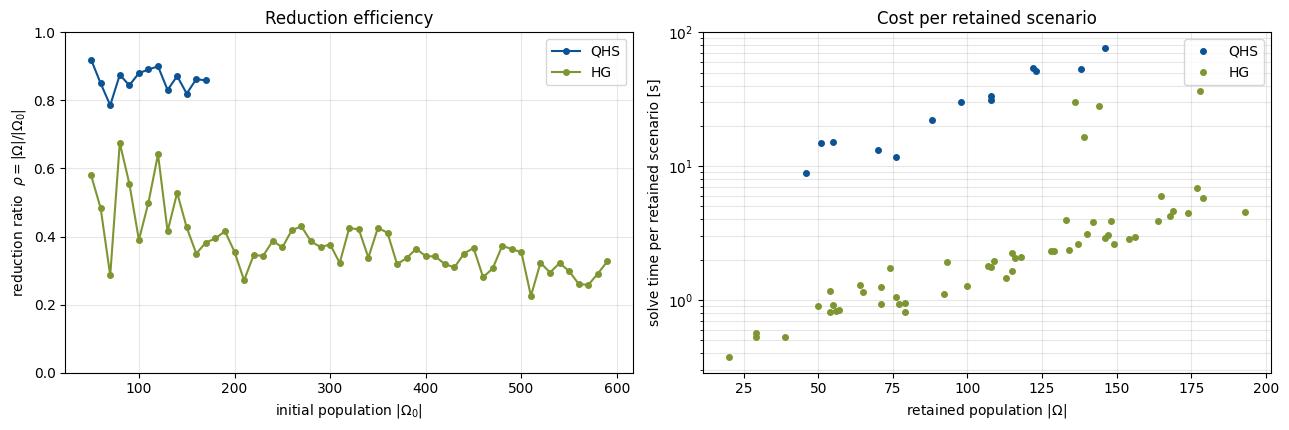

In [17]:
# --- computation -------------------------------------------------------------
efficiency = converged_runs.assign(
    reduction_ratio=converged_runs.pop_retained / converged_runs.pop_initial,
    time_per_retained=converged_runs.solve_time_s / converged_runs.pop_retained,
)

# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR)
for lab in ORDER:
    sub = efficiency[efficiency.formulation == lab].sort_values("pop_initial")
    axes[0].plot(sub["pop_initial"], sub["reduction_ratio"], marker="o", ms=4,
                 lw=1.5, color=COLORS[lab], label=lab)
    # markers only: sorted by |Omega_0| but plotted against |Omega|, which is not
    # monotone in it -- a line here would trace an ordering that does not exist
    axes[1].plot(sub["pop_retained"], sub["time_per_retained"], marker="o", ms=4,
                 lw=0, ls="none", color=COLORS[lab], label=lab)

axes[0].set_xlabel(r"initial population $|\Omega_0|$")
axes[0].set_ylabel(r"reduction ratio  $\rho = |\Omega|/|\Omega_0|$")
axes[0].set_title("Reduction efficiency")
axes[0].set_ylim(0, 1)
axes[1].set_xlabel(r"retained population $|\Omega|$")
axes[1].set_ylabel("solve time per retained scenario [s]")
axes[1].set_title("Cost per retained scenario")
axes[1].set_yscale("log")
for ax in axes:
    ax.grid(alpha=0.3, which="both")
    ax.legend()
fig.tight_layout()
save(fig, "batch_reduction_efficiency")
plt.show()

## Table `tab:cliff`
> *QHS convergence status against scenario-tree size, showing the transition between
> $\lvert\Omega_0\rvert = 170$ and $\lvert\Omega_0\rvert = 180$.*

**Reproducible** via the cross-folder join of section 0.2b. *Status* comes from this
folder's QHS batch CSV; *Tree nodes* and *Effective scenarios* are the 30-day means of
`num_nodes` and `effective_num_scenarios` from the scenario-generation corpus.

In [18]:
# --- computation -------------------------------------------------------------
CLIFF_ROWS = [150, 160, 170, 180, 190, 200, 300]   # the rows the chapter prints

qhs_tree = (runs_with_tree[runs_with_tree.formulation == "QHS"]
            .set_index("pop_initial").sort_index())

last_ok = qhs_tree[qhs_tree.converged].index.max()
first_fail = qhs_tree[~qhs_tree.converged].index.min()

cliff = pd.DataFrame({
    "Status": np.where(qhs_tree.loc[CLIFF_ROWS, "converged"], "ok", "timeout"),
    "Tree nodes": qhs_tree.loc[CLIFF_ROWS, "tree_nodes_30d_mean"],
    "Effective scenarios": qhs_tree.loc[CLIFF_ROWS, "eff_scenarios_30d_mean"],
})
cliff.index.name = "|Omega_0|"

print(f"QHS converges for every |Omega_0| in "
      f"[{qhs_tree[qhs_tree.converged].index.min()}, {last_ok}] and fails for every one in "
      f"[{first_fail}, {qhs_tree.index.max()}]: "
      f"{int(qhs_tree.converged.sum())} consecutive converged runs followed by "
      f"{int((~qhs_tree.converged).sum())} consecutive timeouts")
cliff.round(1)

QHS converges for every |Omega_0| in [50, 170] and fails for every one in [180, 300]: 13 consecutive converged runs followed by 13 consecutive timeouts


,Status,Tree nodes,Effective scenarios
|Omega_0|,,,
150,ok,7515.0,99.8
160,ok,8075.5,103.7
170,ok,8404.6,106.1
180,timeout,8694.4,108.5
190,timeout,9311.0,120.4
200,timeout,9625.1,126.8
300,timeout,13358.6,150.9


In [19]:
# --- the statements made in the paragraph after the table -------------------
nodes_ok = qhs_tree.loc[last_ok, "tree_nodes_30d_mean"]
nodes_fail = qhs_tree.loc[first_fail, "tree_nodes_30d_mean"]
eff_ok = qhs_tree.loc[last_ok, "eff_scenarios_30d_mean"]
eff_fail = qhs_tree.loc[first_fail, "eff_scenarios_30d_mean"]

hg_tree = (runs_with_tree[runs_with_tree.formulation == "HG"]
           .set_index("pop_initial").sort_index())
hg_largest = hg_tree.index.max()

print(f"limit falls between {nodes_ok:.1f} and {nodes_fail:.1f} average tree nodes,")
print(f"  equivalently between {eff_ok:.1f} and {eff_fail:.1f} effective scenarios --")
print(f"  a {(nodes_fail / nodes_ok - 1) * 100:.1f}% increase in tree size separates full "
      f"convergence from complete failure")
print()
print(f"HG reaches {hg_tree.loc[hg_largest, 'tree_nodes_30d_mean']:.0f} tree nodes at "
      f"|Omega_0| = {hg_largest}, "
      f"{hg_tree.loc[hg_largest, 'tree_nodes_30d_mean'] / nodes_fail:.2f}x the QHS node "
      f"count at its own failure point, and converges throughout")
print(f"largest HG configuration solved: |Omega_0| = {hg_largest} with "
      f"|Omega| = {int(hg_tree.loc[hg_largest, 'pop_retained'])}, "
      f"{hg_tree.loc[hg_largest, 'solve_time_s']:.1f} s")

limit falls between 8404.6 and 8694.4 average tree nodes,
  equivalently between 106.1 and 108.5 effective scenarios --
  a 3.4% increase in tree size separates full convergence from complete failure

HG reaches 3882 tree nodes at |Omega_0| = 590, 0.45x the QHS node count at its own failure point, and converges throughout
largest HG configuration solved: |Omega_0| = 590 with |Omega| = 193, 874.4 s


## Figure `fig:sg-cliff` — `figures/sg_tractability_cliff`
> *QHS convergence status against tree size and effective scenario count.*

**Reproducible** via the same join — both of the caption's axes are now available.
Converged and timed-out QHS runs are plotted against 30-day mean tree nodes (left) and
effective scenarios (right), with the limit shown as the band between the last converged
and first failed configuration. HG is drawn for reference, since the chapter's point is
that HG never approaches the QHS limit.

saved  ..\..\TFM_ASP\figures\sg_tractability_cliff.png


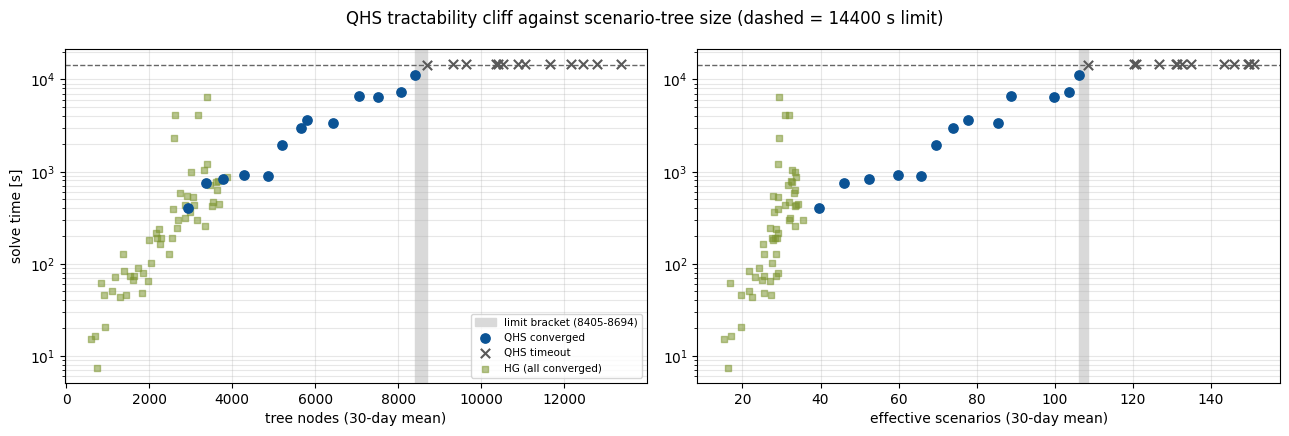

In [20]:
# --- computation -------------------------------------------------------------
CLIFF_PANELS = [("tree_nodes_30d_mean", "tree nodes (30-day mean)"),
                ("eff_scenarios_30d_mean", "effective scenarios (30-day mean)")]

# the limit is not a point but a bracket: last converged .. first failed
cliff_band = {metric: (qhs_tree.loc[last_ok, metric], qhs_tree.loc[first_fail, metric])
              for metric, _ in CLIFF_PANELS}

# --- plotting ----------------------------------------------------------------
SHOW_HG_REFERENCE = True

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR)
for ax, (metric, xlabel) in zip(axes, CLIFF_PANELS):
    lo, hi = cliff_band[metric]
    ax.axvspan(lo, hi, color="0.85", zorder=0,
               label=f"limit bracket ({lo:.0f}-{hi:.0f})")
    for flag, marker, colour, name in [(True, "o", COLORS["QHS"], "QHS converged"),
                                       (False, "x", "0.35", "QHS timeout")]:
        sub = qhs_tree[qhs_tree.converged == flag]
        ax.scatter(sub[metric], sub["solve_time_s"], marker=marker, s=45,
                   color=colour, label=name, zorder=3)
    if SHOW_HG_REFERENCE:
        ax.scatter(hg_tree[metric], hg_tree["solve_time_s"], marker="s", s=18,
                   color=COLORS["HG"], alpha=0.55, label="HG (all converged)", zorder=2)
    ax.axhline(TIME_LIMIT_S, color="0.4", ls="--", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.3, which="both")

axes[0].set_ylabel("solve time [s]")
axes[0].legend(fontsize=7.5, loc="lower right")
fig.suptitle(f"QHS tractability cliff against scenario-tree size "
             f"(dashed = {TIME_LIMIT_S} s limit)")
fig.tight_layout()
save(fig, "sg_tractability_cliff")
plt.show()

---
# 5.2.2 — Optimized values of the two methodologies
`\label{subsec:results-optimized-values}`

## Table `tab:objective-matched`
> *Optimal objective value $RP$ [€] at equal initial population. All converged runs certify
> a gap at or below 1%.*

**Reproducible, and matches the chapter exactly.** `obj_fun` for both formulations over
$\lvert\Omega_0\rvert \in [50, 170]$.

**Sign convention preserved:** $RP$ is negative throughout (the community is a net buyer);
*Difference* is $RP^{\mathrm{QHS}} - RP^{\mathrm{HG}}$, positive because QHS is the less
negative — the better — of the two. Neither column is abs()'d.

In [21]:
# --- computation -------------------------------------------------------------
objective_matched = pd.DataFrame({
    "RP_QHS": q_span["obj_fun"],
    "RP_HG": h_span["obj_fun"],
})
# Difference = QHS - HG, positive when QHS is the less negative (better) objective.
objective_matched["Difference"] = objective_matched["RP_QHS"] - objective_matched["RP_HG"]
objective_matched["% of |RP_HG|"] = (objective_matched["Difference"]
                                     / objective_matched["RP_HG"].abs() * 100)
objective_matched.index.name = "|Omega_0|"

objective_matched.loc["mean"] = objective_matched.mean()
objective_matched.round(1)

,RP_QHS,RP_HG,Difference,% of |RP_HG|
|Omega_0|,,,,
50,-28014.4,-39356.5,11342.1,28.8
60,-26373.9,-38610.5,12236.6,31.7
70,-27611.0,-39225.1,11614.2,29.6
80,-28684.2,-37592.0,8907.8,23.7
90,-27572.1,-38745.5,11173.4,28.8
100,-25736.9,-39359.7,13622.8,34.6
110,-29340.0,-38411.1,9071.1,23.6
120,-26271.7,-38149.7,11878.0,31.1
130,-27595.1,-37738.1,10142.9,26.9


In [22]:
# --- the statements made in the paragraphs after the table -------------------
body = objective_matched.drop(index="mean")
print(f"ordering RP_HG <= RP_QHS holds at all {len(body)} matched populations: "
      f"{bool((body['RP_HG'] <= body['RP_QHS']).all())}")
print(f"difference: mean {body['Difference'].mean():.0f} EUR "
      f"({body['% of |RP_HG|'].mean():.1f}% of |RP_HG|), "
      f"range {body['Difference'].min():.1f} ({body['% of |RP_HG|'].min():.1f}%) to "
      f"{body['Difference'].max():.1f} ({body['% of |RP_HG|'].max():.1f}%)")
print()
print("at the four equal-retained-count configurations:")
matched_obj = pd.DataFrame({
    c: {"RP_QHS": at_matched("QHS", c, "obj_fun"), "RP_HG": at_matched("HG", c, "obj_fun")}
    for c in MATCHED_COUNTS}).T
matched_obj["Difference"] = matched_obj["RP_QHS"] - matched_obj["RP_HG"]
matched_obj["% of |RP_HG|"] = matched_obj["Difference"] / matched_obj["RP_HG"].abs() * 100
matched_obj.index.name = "|Omega|"
print(f"  ordering holds at all four: {bool((matched_obj.RP_HG <= matched_obj.RP_QHS).all())}")
print()
# dispersion of each objective series across its own full range
spread = ok.groupby("formulation")["obj_fun"].agg(["count", "mean", "std", "min", "max"])
spread["cv_%"] = spread["std"] / spread["mean"].abs() * 100
print(spread.round(2).to_string())
matched_obj.round(1)

ordering RP_HG <= RP_QHS holds at all 13 matched populations: True
difference: mean 10813 EUR (28.1% of |RP_HG|), range 8907.8 (23.6%) to 13622.8 (34.6%)

at the four equal-retained-count configurations:
  ordering holds at all four: True

             count      mean      std       min       max  cv_%
formulation                                                    
HG              55 -38270.51   617.22 -39529.86 -36350.91  1.61
QHS             13 -27602.36  1044.12 -29339.98 -25736.92  3.78


,RP_QHS,RP_HG,Difference,% of |RP_HG|
|Omega|,,,,
55,-27611.0,-38411.1,10800.2,28.1
76,-27572.1,-38762.3,11190.3,28.9
108,-27595.1,-37767.7,10172.6,26.9
146,-26860.6,-39026.4,12165.8,31.2


## Table `tab:objective-components`
> *Objective components [€], averaged over the matched initial-population range $[50,170]$.
> Sign convention follows eq:dem-obj: a negative day-ahead term denotes net purchases.*

**Reproducible.** Mean of `obj_DA_income`, `obj_RM_income`, `obj_IM_income`, `obj_IB_net`
and `obj_FD_costs` over $\lvert\Omega_0\rvert \in [50, 170]$.

**Sign convention preserved exactly:** day-ahead is negative (net purchase), reserve and
intraday positive (income), imbalance negative (net cost). *Difference* is QHS − HG, so a
negative difference means HG earns/spends more on that component. No absolute values.

In [23]:
# --- computation -------------------------------------------------------------
components = pd.DataFrame({
    "QHS": q_span[list(OBJ_COMPONENTS)].mean(),
    "HG": h_span[list(OBJ_COMPONENTS)].mean(),
})
components["Difference"] = components["QHS"] - components["HG"]     # QHS - HG
components.index = components.index.map(OBJ_COMPONENTS)

# Total row: the objective itself, not the sum of the parts (they need not agree
# exactly if any term is excluded from obj_fun -- checked below).
components.loc["Total"] = [q_span["obj_fun"].mean(), h_span["obj_fun"].mean(),
                           q_span["obj_fun"].mean() - h_span["obj_fun"].mean()]

components.round(1)

,QHS,HG,Difference
Day-ahead,-37503.2,-50544.6,13041.4
Reserve market,5715.8,5942.4,-226.6
Intraday,4499.9,6630.2,-2130.3
"Imbalance, net",-221.7,-335.9,114.1
Flexible demand,93.2,107.6,-14.4
Total,-27602.4,-38415.4,10813.0


### ⚠️ Sign note: the component column does not sum to its own Total

Read additively, the five components come to **−27 416.0 €** (QHS) and **−38 307.9 €** (HG),
while the Total row — the actual objective — is **−27 602.4** and **−38 415.4**. The
residual is exactly $2 \times$ the flexible-demand entry in each case
(+186.4 = 2 × 93.2; +215.2 = 2 × 107.6).

The reason: `obj_FD_costs` is a **cost**, entering the objective with a minus sign, but the
table displays it as a positive number in a column whose other entries are signed to be
added. Subtracting it instead reconciles the two to the cent:

$$-37\,503.2 + 5\,715.8 + 4\,499.9 - 221.7 \;\mathbf{-}\; 93.2 = -27\,602.4$$

Per the brief, the sign is **not** silently flipped below — the table is rendered exactly as
the chapter presents it, and the reconciliation is shown alongside so the discrepancy stays
visible. If the chapter's table is to be made self-consistent, the flexible-demand row
should read $-93.2$ / $-107.6$, or the column should be relabelled as magnitudes with the
sign carried in the header.

In [24]:
# --- reconciliation: which sign convention makes the parts equal the whole? --
# `obj_FD_costs` is a COST: it enters eq:dem-obj negatively. Every other component
# is already signed (DA negative = purchase, RM/IM positive = income, IB net negative).
ADDITIVE = ["Day-ahead", "Reserve market", "Intraday", "Imbalance, net"]

reconciliation = pd.DataFrame({
    "sum as displayed (FD added)": components.loc[list(OBJ_COMPONENTS.values()), ORDER].sum(),
    "sum with FD subtracted": (components.loc[ADDITIVE, ORDER].sum()
                               - components.loc["Flexible demand", ORDER]),
    "obj_fun (Total row)": components.loc["Total", ORDER],
}).T
reconciliation.loc["residual, FD added"] = (reconciliation.loc["sum as displayed (FD added)"]
                                            - reconciliation.loc["obj_fun (Total row)"])
reconciliation.loc["residual, FD subtracted"] = (reconciliation.loc["sum with FD subtracted"]
                                                 - reconciliation.loc["obj_fun (Total row)"])
print("2 x flexible-demand entry:",
      {lab: round(2 * components.loc["Flexible demand", lab], 2) for lab in ORDER})
reconciliation.round(2)

2 x flexible-demand entry: {'QHS': np.float64(186.33), 'HG': np.float64(215.14)}


,QHS,HG
sum as displayed (FD added),-27416.03,-38200.24
sum with FD subtracted,-27602.36,-38415.39
obj_fun (Total row),-27602.36,-38415.39
"residual, FD added",186.33,215.14
"residual, FD subtracted",0.00,0.00


In [25]:
# --- the statements made in the paragraph after the table --------------------
comp = components.drop(index="Total")
print(f"day-ahead difference {comp.loc['Day-ahead','Difference']:.1f} EUR "
      f"exceeds the total objective gap {components.loc['Total','Difference']:.1f} EUR: "
      f"{comp.loc['Day-ahead','Difference'] > components.loc['Total','Difference']}")
print()
print("components moving in the opposite direction (HG ahead of QHS):")
for name, row in comp.iterrows():
    if row["Difference"] < 0:
        print(f"  {name}: HG ahead by {-row['Difference']:.1f} EUR")
print()
rm = comp.loc["Reserve market"]
print(f"reserve income differs by {abs(rm['Difference'])/abs(rm['HG'])*100:.1f}% "
      f"of its own magnitude - the most similar component")

day-ahead difference 13041.4 EUR exceeds the total objective gap 10813.0 EUR: True

components moving in the opposite direction (HG ahead of QHS):
  Reserve market: HG ahead by 226.6 EUR
  Intraday: HG ahead by 2130.3 EUR
  Flexible demand: HG ahead by 14.4 EUR

reserve income differs by 3.8% of its own magnitude - the most similar component


## Figure `fig:batch-obj` — `figures/batch_obj_vs_count`
> *Objective value against scenario count for both formulations.*

**Reproducible.** `obj_fun` against initial and retained population. The y-axis is left in
its natural negative orientation — a **less negative value is a better one**, and flipping
or abs()-ing it would invert the reading.

saved  ..\..\TFM_ASP\figures\batch_obj_vs_count.png


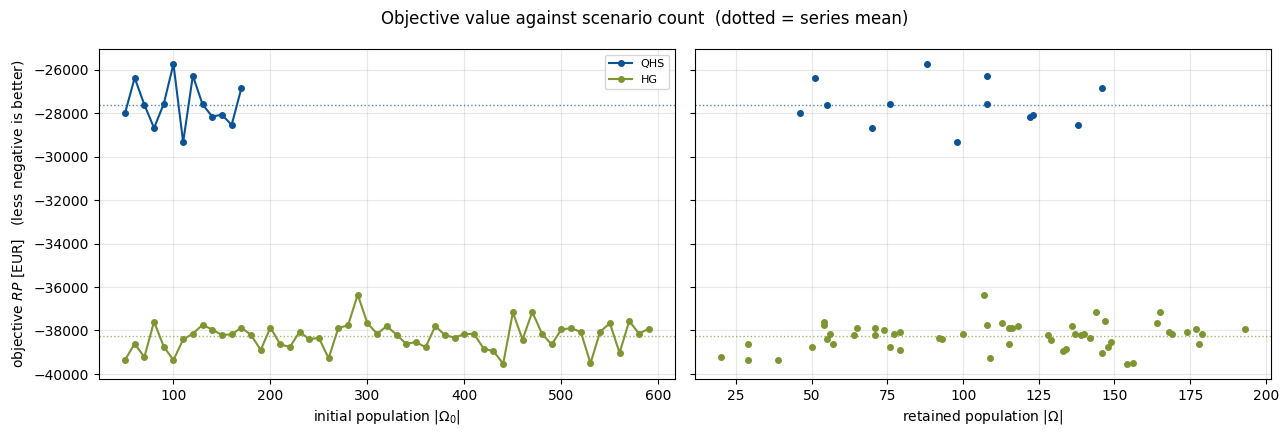

In [26]:
# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PAIR, sharey=True)
for ax, xcol, xlabel in [
        (axes[0], "pop_initial", r"initial population $|\Omega_0|$"),
        (axes[1], "pop_retained", r"retained population $|\Omega|$")]:
    for lab in ORDER:
        sub = ok[ok.formulation == lab].sort_values(xcol)
        joined = xcol == "pop_initial"          # see the note in fig:batch-time
        ax.plot(sub[xcol], sub["obj_fun"], marker="o", ms=4,
                lw=1.5 if joined else 0, ls="-" if joined else "none",
                color=COLORS[lab], label=lab)
        ax.axhline(sub["obj_fun"].mean(), color=COLORS[lab], ls=":", lw=1, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r"objective $RP$ [EUR]   (less negative is better)")
axes[0].legend(fontsize=8)
fig.suptitle("Objective value against scenario count  (dotted = series mean)")
fig.tight_layout()
save(fig, "batch_obj_vs_count")
plt.show()

## Figure `fig:batch-obj-components` — `figures/batch_obj_components`
> *Objective components against scenario count for both formulations.*

**Reproducible.** One panel per component, both formulations, against initial population.
Signs are preserved: the day-ahead panel sits below zero, reserve and intraday above.

saved  ..\..\TFM_ASP\figures\batch_obj_components.png


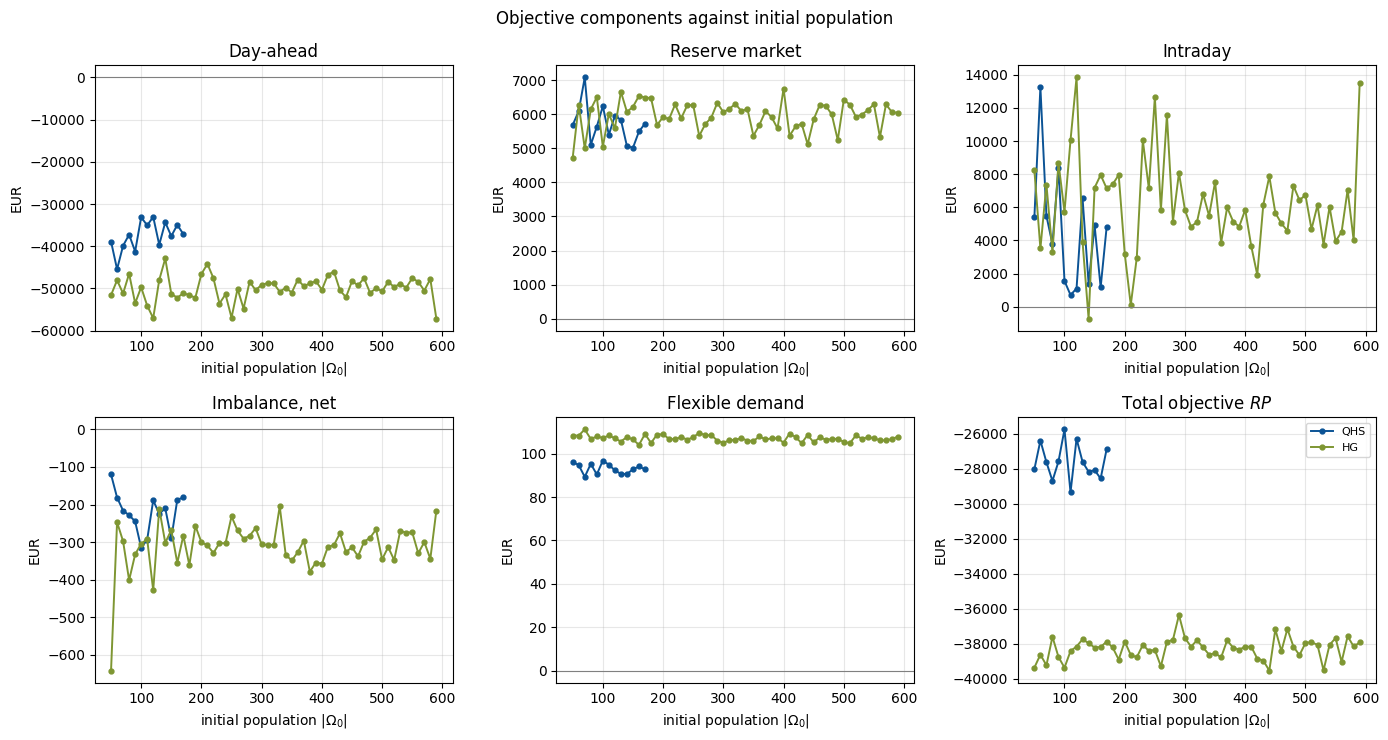

In [27]:
# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, (col, name) in zip(axes.ravel(), OBJ_COMPONENTS.items()):
    for lab in ORDER:
        sub = ok[ok.formulation == lab].sort_values("pop_initial")
        ax.plot(sub["pop_initial"], sub[col], marker="o", ms=3.5, lw=1.4,
                color=COLORS[lab], label=lab)
    ax.axhline(0, color="0.5", lw=0.8)           # sign boundary: income vs cost
    ax.set_title(name)
    ax.set_xlabel(r"initial population $|\Omega_0|$")
    ax.set_ylabel("EUR")
    ax.grid(alpha=0.3)

# last panel: the total objective, for reference
ax = axes.ravel()[len(OBJ_COMPONENTS)]
for lab in ORDER:
    sub = ok[ok.formulation == lab].sort_values("pop_initial")
    ax.plot(sub["pop_initial"], sub["obj_fun"], marker="o", ms=3.5, lw=1.4,
            color=COLORS[lab], label=lab)
ax.set_title("Total objective $RP$")
ax.set_xlabel(r"initial population $|\Omega_0|$")
ax.set_ylabel("EUR")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.suptitle("Objective components against initial population")
fig.tight_layout()
save(fig, "batch_obj_components")
plt.show()

---
# The deep-dive items at $\lvert\Omega\rvert = 146$

Everything from here on is computed at the largest matched retained count,
$\lvert\Omega\rvert = 146$ — $\lvert\Omega_0\rvert = 170$ under QHS and $560$ under HG —
over **96 quarter-hourly periods × 146 retained scenarios** (14 016 period–scenario pairs
per variable).

The batch CSVs carry none of this. It comes instead from the per-run solution exports under
`results/FTC_20251031_20251130_c30_sc<N>_15min_<branch>/DA/`, whose layout is:

| Path | Contents |
|---|---|
| `market/001/DA/` | `eDA_m`, `eDA_p`, `ieDA_m`, `ieDA_p`, `lD` (price) |
| `market/001/RM/` | `rU`, `rD`, `rU_B`, `rD_B`, `rU_FD`, `rD_FD`, `lR` |
| `market/001/IM/` | `eIM_1..3`, `eIM_TOT`, `lI_1..3` |
| `market/001/IB/` | `pIB_p`, `pIB_m`, `lPIB`, `lNIB` |
| `ec/001/BESS/` | `cV`, `dV`, `cV-dV`, `socV`, `idV` |
| `ec/001/FD/` | `var_fd`, `var_afd_p`, `var_afd_m` |
| `ec/001/PV`, `ec/001/WP` | `pPV`, `pW` |

**File format.** Every file is whitespace-delimited with one row per retained scenario:
`<scenario_id> <probability> <96 values>`. `socV` carries **97** values — the initial state
at $t = 0$ plus 96 post-decision states.

Two data issues found while reading these, both handled explicitly below:

1. **`eIM_TOT.txt` is truncated under QHS** — 143 of 146 rows, the last cut mid-write. The
   total is therefore computed as `eIM_1 + eIM_2 + eIM_3`, which reproduces the chapter's
   $-0.5786$ exactly.
2. **Files can read as empty while OneDrive is still hydrating them.** The loader retries
   and validates the expected shape, so a partially-synced file raises instead of silently
   producing a wrong mean.

In [28]:
import os
import time

# --- deep-dive configuration -------------------------------------------------
RESULTS_ROOT = "results"
RUN_TEMPLATE = "FTC_20251031_20251130_c30_sc{pop}_15min_{branch}"
BRANCH = {"QHS": "different_ren", "HG": "same_ren"}

# The chapter's deep-dive pair: the largest retained count both formulations reach.
DEEP_DIVE_COUNT = 146
DEEP_DIVE_POP = {c: matched[c] for c in MATCHED_COUNTS}[DEEP_DIVE_COUNT]

N_PERIODS = 96           # quarter-hours in the scheduling day
HYDRATION_RETRIES = 6    # OneDrive can serve an empty file while still syncing
HYDRATION_WAIT_S = 0.8


def run_dir(label, pop):
    return os.path.join(RESULTS_ROOT, RUN_TEMPLATE.format(pop=pop, branch=BRANCH[label]), "DA")


def load_var(label, pop, rel, width=N_PERIODS, n_scen=None, required=True):
    """Read one exported variable as (probabilities, values[n_scenarios, width]).

    Each scenario contributes `2 + width` numbers: scenario id, probability, then
    the per-period values. THE LINE LAYOUT DIFFERS BETWEEN THE TWO FORMULATIONS:
    QHS writes all 96 values on one line (98 tokens per line), while HG wraps the
    IM and IB files at 4 values per line -- 24 stage-lines of 4 quarter-hours each,
    which is HG's hourly stage grid. Parsing the file as a flat token stream and
    reshaping is therefore layout-agnostic and correct for both; parsing line by
    line silently mis-reads the HG files as 4-period series.

    Retries because OneDrive can serve a file as empty while still syncing, and
    validates the token count so a partially-written file raises rather than
    yielding a wrong statistic.
    """
    n_scen = n_scen or DEEP_DIVE_COUNT
    path = os.path.join(run_dir(label, pop), *rel.split("/"))
    expected = n_scen * (2 + width)
    for _ in range(HYDRATION_RETRIES):
        try:
            tokens = open(path).read().split()
        except OSError:
            tokens = []
        if len(tokens) == expected:
            arr = np.array(tokens, dtype=float).reshape(n_scen, 2 + width)
            return arr[:, 1], arr[:, 2:], 0
        if tokens:
            short = len(tokens)
            time.sleep(HYDRATION_WAIT_S)
        else:
            short = 0
            time.sleep(HYDRATION_WAIT_S)
    if required:
        raise IOError(f"{path}: expected {expected} tokens for {n_scen} scenarios "
                      f"x {width} periods, found {short}")
    return None, None, short


print("deep-dive configurations:")
for lab in ORDER:
    pop = DEEP_DIVE_POP[lab]
    print(f"  {lab:4s} |Omega_0|={pop:3d} -> {run_dir(lab, pop)}")

deep-dive configurations:
  QHS  |Omega_0|=170 -> results\FTC_20251031_20251130_c30_sc170_15min_different_ren\DA
  HG   |Omega_0|=560 -> results\FTC_20251031_20251130_c30_sc560_15min_same_ren\DA


In [29]:
# --- hydration / integrity check before anything is computed -----------------
CHECK_FILES = [
    ("market/001/DA/eDA_m.txt", N_PERIODS), ("market/001/DA/eDA_p.txt", N_PERIODS),
    ("market/001/DA/lD.txt", N_PERIODS),
    ("market/001/RM/rU.txt", N_PERIODS), ("market/001/RM/rD.txt", N_PERIODS),
    ("market/001/RM/rU_B.txt", N_PERIODS), ("market/001/RM/rD_B.txt", N_PERIODS),
    ("market/001/RM/rU_FD.txt", N_PERIODS), ("market/001/RM/rD_FD.txt", N_PERIODS),
    ("market/001/RM/lR.txt", N_PERIODS),
    ("market/001/IM/eIM_1.txt", N_PERIODS), ("market/001/IM/eIM_2.txt", N_PERIODS),
    ("market/001/IM/eIM_3.txt", N_PERIODS), ("market/001/IM/lI_1.txt", N_PERIODS),
    ("market/001/IM/lI_2.txt", N_PERIODS), ("market/001/IM/lI_3.txt", N_PERIODS),
    ("market/001/IB/pIB_p.txt", N_PERIODS), ("market/001/IB/pIB_m.txt", N_PERIODS),
    ("market/001/IB/lPIB.txt", N_PERIODS), ("market/001/IB/lNIB.txt", N_PERIODS),
    ("ec/001/BESS/cV.txt", N_PERIODS), ("ec/001/BESS/dV.txt", N_PERIODS),
    ("ec/001/BESS/cV-dV.txt", N_PERIODS), ("ec/001/BESS/idV.txt", N_PERIODS),
    ("ec/001/BESS/socV.txt", N_PERIODS + 1),      # extra initial state at t=0
    ("ec/001/FD/var_fd.txt", N_PERIODS), ("ec/001/FD/var_afd_p.txt", N_PERIODS),
    ("ec/001/FD/var_afd_m.txt", N_PERIODS),
    ("ec/001/PV/pPV.txt", N_PERIODS), ("ec/001/WP/pW.txt", N_PERIODS),
]

integrity = []
for lab in ORDER:
    pop = DEEP_DIVE_POP[lab]
    for rel, width in CHECK_FILES:
        prob, vals, dropped = load_var(lab, pop, rel, width, required=False)
        integrity.append({
            "formulation": lab, "file": rel,
            "scenarios": 0 if vals is None else vals.shape[0],
            "periods": 0 if vals is None else vals.shape[1],
            "token shortfall": dropped,
            "prob sums to 1": None if prob is None else bool(np.isclose(prob.sum(), 1.0)),
        })

integrity = pd.DataFrame(integrity)
bad = integrity[(integrity["scenarios"] != DEEP_DIVE_COUNT)
                | (integrity["token shortfall"] > 0)]
print(f"files checked: {len(integrity)}   fully intact: {len(integrity) - len(bad)}")
if len(bad):
    print("\nfiles NOT at the expected 146 scenarios, or with rows dropped:")
    print(bad.to_string(index=False))
else:
    print("all files present at 146 scenarios x expected width, probabilities sum to 1")
bad if len(bad) else integrity.head(6)

files checked: 60   fully intact: 60
all files present at 146 scenarios x expected width, probabilities sum to 1


,formulation,file,scenarios,periods,token shortfall,prob sums to 1
0,QHS,market/001/DA/eDA_m.txt,146,96,0,True
1,QHS,market/001/DA/eDA_p.txt,146,96,0,True
2,QHS,market/001/DA/lD.txt,146,96,0,True
3,QHS,market/001/RM/rU.txt,146,96,0,True
4,QHS,market/001/RM/rD.txt,146,96,0,True
5,QHS,market/001/RM/rU_B.txt,146,96,0,True


In [30]:
# --- load every deep-dive variable once --------------------------------------
# name -> (relative path, width). eIM_TOT is deliberately absent: it is derived
# from the three sessions because the QHS export of it is truncated.
VAR_FILES = {
    "eDA_m": ("market/001/DA/eDA_m.txt", N_PERIODS),
    "eDA_p": ("market/001/DA/eDA_p.txt", N_PERIODS),
    "ieDA_m": ("market/001/DA/ieDA_m.txt", N_PERIODS),
    "lD": ("market/001/DA/lD.txt", N_PERIODS),
    "rU": ("market/001/RM/rU.txt", N_PERIODS),
    "rD": ("market/001/RM/rD.txt", N_PERIODS),
    "rU_B": ("market/001/RM/rU_B.txt", N_PERIODS),
    "rD_B": ("market/001/RM/rD_B.txt", N_PERIODS),
    "rU_FD": ("market/001/RM/rU_FD.txt", N_PERIODS),
    "rD_FD": ("market/001/RM/rD_FD.txt", N_PERIODS),
    "lR": ("market/001/RM/lR.txt", N_PERIODS),
    "eIM_1": ("market/001/IM/eIM_1.txt", N_PERIODS),
    "eIM_2": ("market/001/IM/eIM_2.txt", N_PERIODS),
    "eIM_3": ("market/001/IM/eIM_3.txt", N_PERIODS),
    "lI_1": ("market/001/IM/lI_1.txt", N_PERIODS),
    "lI_2": ("market/001/IM/lI_2.txt", N_PERIODS),
    "lI_3": ("market/001/IM/lI_3.txt", N_PERIODS),
    "pIB_p": ("market/001/IB/pIB_p.txt", N_PERIODS),
    "pIB_m": ("market/001/IB/pIB_m.txt", N_PERIODS),
    "lPIB": ("market/001/IB/lPIB.txt", N_PERIODS),
    "lNIB": ("market/001/IB/lNIB.txt", N_PERIODS),
    "cV": ("ec/001/BESS/cV.txt", N_PERIODS),
    "dV": ("ec/001/BESS/dV.txt", N_PERIODS),
    "net_charge": ("ec/001/BESS/cV-dV.txt", N_PERIODS),
    "idV": ("ec/001/BESS/idV.txt", N_PERIODS),
    "socV": ("ec/001/BESS/socV.txt", N_PERIODS + 1),
    "var_fd": ("ec/001/FD/var_fd.txt", N_PERIODS),
    "var_afd_p": ("ec/001/FD/var_afd_p.txt", N_PERIODS),
    "var_afd_m": ("ec/001/FD/var_afd_m.txt", N_PERIODS),
    "pPV": ("ec/001/PV/pPV.txt", N_PERIODS),
    "pW": ("ec/001/WP/pW.txt", N_PERIODS),
}

deep = {}
for lab in ORDER:
    pop = DEEP_DIVE_POP[lab]
    store = {}
    for name, (rel, width) in VAR_FILES.items():
        prob, vals, _ = load_var(lab, pop, rel, width)
        store[name] = vals
        store.setdefault("_prob", prob)
    # eIM_TOT is DERIVED from the three sessions rather than read: the QHS
    # eIM_TOT.txt export has been seen truncated (143 of 146 scenarios, the last
    # row cut mid-write). The stored file is cross-checked against the derivation
    # below whenever it is intact.
    store["eIM_TOT"] = store["eIM_1"] + store["eIM_2"] + store["eIM_3"]
    _, stored_total, _ = load_var(lab, pop, "market/001/IM/eIM_TOT.txt",
                                  N_PERIODS, required=False)
    store["_eIM_TOT_file_ok"] = (
        None if stored_total is None
        else bool(np.allclose(stored_total, store["eIM_TOT"], atol=1e-9)))
    # socV excluding the initial state, which is what the chapter's statistics use
    store["soc"] = store["socV"][:, 1:]
    deep[lab] = store

for lab in ORDER:
    d = deep[lab]
    flag = {True: "matches derivation", False: "DISAGREES", None: "truncated/unreadable"}
    print(f"{lab:4s} |Omega|={d['eDA_m'].shape[0]}  periods={d['eDA_m'].shape[1]}  "
          f"prob sum={d['_prob'].sum():.6f}  soc initial={d['socV'][:, 0].mean():.4f}  "
          f"eIM_TOT file: {flag[d['_eIM_TOT_file_ok']]}")

QHS  |Omega|=146  periods=96  prob sum=1.000000  soc initial=0.4000  eIM_TOT file: matches derivation
HG   |Omega|=146  periods=96  prob sum=1.000000  soc initial=0.4000  eIM_TOT file: matches derivation


## Table `tab:decisions-matched`
> *Descriptive statistics of the decision variables at $\lvert\Omega\rvert = 146$, over 96
> periods × 146 scenarios. P10 and P90 are the 10th and 90th percentiles across all
> period–scenario pairs.*

**Reproducible.** Statistics are **unweighted** over all 14 016 period–scenario pairs, as
the chapter specifies ("*not probability-weighted*"). `Std` uses the sample convention
(ddof=1), which is what reproduces the published values.

**Signs preserved:** $e^{IM}_{2}$, $e^{IM}_{3}$, $e^{IM}$ and net charge are genuinely
signed — a negative net charge means the battery is a net *discharger*. Nothing is
abs()'d.

### 🔎 The QHS imbalance row can now be filled

The chapter leaves $p^{IB-}$ and $p^{IB+}$ blank for QHS, recording a `[DATA DEFECT]`: the
QHS run "did not export `pIB_p`, `pIB_m`, `lPIB` or `lNIB`", and its loader reported an
unidentifiable variable named `{var_name}` — an unresolved f-string — with *"mean 0.0821,
59.34% zeros and max 1.1652 MWh"*.

All four files are present in this export, and QHS `pIB_m` reads **mean 0.0821, 59.34%
zeros, max 1.1652** — an exact three-way match. **The unidentified variable was
$p^{IB-}$.** Both QHS imbalance rows are filled below.

In [31]:
# --- computation -------------------------------------------------------------
# (display name, unit, key). Order follows the chapter's table exactly.
DECISION_ROWS = [
    ("e^{DA-}", "MWh", "eDA_m"), ("e^{DA+}", "MWh", "eDA_p"),
    ("r^{U}", "MW", "rU"), ("r^{D}", "MW", "rD"),
    ("r^{U}_{B}", "MW", "rU_B"), ("r^{D}_{B}", "MW", "rD_B"),
    ("r^{U}_{FD}", "MW", "rU_FD"), ("r^{D}_{FD}", "MW", "rD_FD"),
    ("e^{IM}_{1}", "MWh", "eIM_1"), ("e^{IM}_{2}", "MWh", "eIM_2"),
    ("e^{IM}_{3}", "MWh", "eIM_3"), ("e^{IM} (total)", "MWh", "eIM_TOT"),
    ("soc", "MWh", "soc"), ("net charge", "MW", "net_charge"),
    ("i^{d} (discharge state)", "-", "idV"),
    ("central demand", "MW", "var_fd"),
    ("displacement +", "MW", "var_afd_p"), ("displacement -", "MW", "var_afd_m"),
    ("p^{IB-}", "MWh", "pIB_m"), ("p^{IB+}", "MWh", "pIB_p"),
]


def describe(values):
    """Unweighted descriptive statistics over all period-scenario pairs."""
    flat = values.ravel()
    return {
        "Mean": flat.mean(),
        "Std": flat.std(ddof=1),           # sample std, matches the published table
        "% zero": (flat == 0).mean() * 100,
        "Min": flat.min(), "P10": np.percentile(flat, 10),
        "Median": np.median(flat), "P90": np.percentile(flat, 90), "Max": flat.max(),
    }


decisions = pd.concat(
    {lab: pd.DataFrame({name: describe(deep[lab][key]) for name, _, key in DECISION_ROWS}).T
     for lab in ORDER}, axis=1)
# keep the (formulation, statistic) MultiIndex intact; carry Unit as its own level-0 entry
units = pd.DataFrame({("", "Unit"): [unit for _, unit, _ in DECISION_ROWS]},
                     index=decisions.index)
decisions = pd.concat([units, decisions], axis=1)

# the three columns the chapter prints
CHAPTER_STATS = ["Mean", "Std", "% zero"]
decisions_chapter = decisions[[("", "Unit")]
                              + [(lab, c) for lab in ORDER for c in CHAPTER_STATS]]
decisions_chapter.round(4)

QHS                        HG                  
                        Unit    Mean     Std    % zero    Mean     Std    % zero
e^{DA-}                  MWh  4.9205  2.6916    0.0000  6.2744  3.4170    0.0000
e^{DA+}                  MWh  0.0000  0.0000  100.0000  0.0000  0.0000  100.0000
r^{U}                     MW  4.4241  2.4080   11.5725  4.4284  2.5721   12.7783
r^{D}                     MW  6.8913  5.0554   12.4857  7.2943  5.3165   16.8522
r^{U}_{B}                 MW  2.7277  1.7204   16.1030  2.7608  1.6158   17.3944
r^{D}_{B}                 MW  2.4938  1.5451   15.8105  2.6305  1.5413   19.0568
r^{U}_{FD}                MW  1.6964  1.2269   31.3784  1.6676  1.4256   38.3134
r^{D}_{FD}                MW  4.3975  4.0436   37.5713  4.6638  4.3374   42.3516
e^{IM}_{1}               MWh  0.4077  1.4445   60.6093  0.2370  1.5933   37.1932
e^{IM}_{2}               MWh  0.1168  1.4143   50.9418 -0.1992  1.4743   40.7035
e^{IM}_{3}               MWh -1.1031  1.3987   48.9726  0.4099  1.8698   48.1378
e^{IM} (total)           MWh -0.5786  2.5948    0.0000  0.4477  2.1001    0.0000
soc                      MWh  0.4954  0.2494    0.0000  0.5657  0.2769    0.0000
net charge                MW  0.0970  1.5068   47.4743 -0.0871  1.5135   63.7486
i^{d} (discharge state)    -  0.6050  0.4889   39.5049  0.2779  0.4480   72.2103
central demand            MW  6.1154  1.8511    0.0000  6.6208  2.1428    0.0000
displacement +            MW  0.4821  0.5007   43.2149  0.5582  0.5344   41.1458
displacement -            MW  0.4821  0.6400   60.9946  0.5582  0.7233   61.0231
p^{IB-}                  MWh  0.0821  0.1414   59.3393  0.0580  0.1194   67.3159
p^{IB+}                  MWh  0.1021  0.2215   67.3659  0.0379  0.1562   90.9960

In [32]:
# --- the full statistics, including the P10/P90/min/max quoted in the prose --
decisions.round(4)

QHS                                                                  HG                                                            
                        Unit    Mean     Std    % zero     Min     P10  Median      P90      Max    Mean     Std    % zero     Min     P10  Median      P90      Max
e^{DA-}                  MWh  4.9205  2.6916    0.0000  0.1204  1.9433  4.6141   8.6800  11.0300  6.2744  3.4170    0.0000  2.3220  2.5607  4.2720  10.2200  10.7000
e^{DA+}                  MWh  0.0000  0.0000  100.0000  0.0000  0.0000  0.0000   0.0000   0.0000  0.0000  0.0000  100.0000  0.0000  0.0000  0.0000   0.0000   0.0000
r^{U}                     MW  4.4241  2.4080   11.5725  0.0000  0.0000  5.0170   7.7400   8.9300  4.4284  2.5721   12.7783  0.0000  0.0000  4.8200   8.0833   9.3200
r^{D}                     MW  6.8913  5.0554   12.4857  0.0000  0.0000  7.0400  13.6800  18.6800  7.2943  5.3165   16.8522  0.0000  0.0000  8.4600  14.1320  18.1470
r^{U}_{B}                 MW  2.7277  1.7204   16.1030  0.0000  0.0000  3.0000   5.7391   6.0000  2.7608  1.6158   17.3944  0.0000  0.0000  3.0000   5.8169   6.0000
r^{D}_{B}                 MW  2.4938  1.5451   15.8105  0.0000  0.0000  3.0000   3.7350   6.0000  2.6305  1.5413   19.0568  0.0000  0.0000  3.0000   3.0000   6.0000
r^{U}_{FD}                MW  1.6964  1.2269   31.3784  0.0000  0.0000  2.2000   2.9300   3.1800  1.6676  1.4256   38.3134  0.0000  0.0000  2.1600   3.1600   3.3200
r^{D}_{FD}                MW  4.3975  4.0436   37.5713  0.0000  0.0000  5.2200   9.1486  12.7200  4.6638  4.3374   42.3516  0.0000  0.0000  5.9600   9.9200  12.3200
e^{IM}_{1}               MWh  0.4077  1.4445   60.6093 -2.3336 -0.1393  0.0000   3.5410   5.5150  0.2370  1.5933   37.1932 -2.2505 -1.5760  0.0000   3.4803   4.9950
e^{IM}_{2}               MWh  0.1168  1.4143   50.9418 -2.3336 -1.2512  0.0000   0.3002   5.5150 -0.1992  1.4743   40.7035 -2.6463 -1.5778  0.0000   0.6340   4.9950
e^{IM}_{3}               MWh -1.1031  1.3987   48.9726 -3.3287 -2.8905 -0.5553   0.0000   5.5150  0.4099  1.8698   48.1378 -2.6405 -1.6553  0.0000   3.4120   4.9950
e^{IM} (total)           MWh -0.5786  2.5948    0.0000 -3.3287 -2.8905 -1.5366   4.1975   5.5150  0.4477  2.1001    0.0000 -2.6463 -1.7064 -0.6597   3.5759   4.9950
soc                      MWh  0.4954  0.2494    0.0000  0.1000  0.1428  0.4035   0.8250   0.9000  0.5657  0.2769    0.0000  0.1000  0.1938  0.7312   0.8250   0.9000
net charge                MW  0.0970  1.5068   47.4743 -3.0000 -2.6472  0.0000   2.8374   3.0000 -0.0871  1.5135   63.7486 -3.0000 -3.0000  0.0000   3.0000   3.0000
i^{d} (discharge state)    -  0.6050  0.4889   39.5049  0.0000  0.0000  1.0000   1.0000   1.0000  0.2779  0.4480   72.2103  0.0000  0.0000  0.0000   1.0000   1.0000
central demand            MW  6.1154  1.8511    0.0000  3.4900  3.8400  5.9931   8.4600   9.5400  6.6208  2.1428    0.0000  3.6400  3.8000  6.3575   9.4700   9.9500
displacement +            MW  0.4821  0.5007   43.2149  0.0000  0.0000  0.4490   1.1000   1.5900  0.5582  0.5344   41.1458  0.0000  0.0000  0.5475   1.3800   1.5400
displacement -            MW  0.4821  0.6400   60.9946  0.0000  0.0000  0.0000   1.4000   1.5900  0.5582  0.7233   61.0231  0.0000  0.0000  0.0000   1.5800   1.6500
p^{IB-}                  MWh  0.0821  0.1414   59.3393  0.0000  0.0000  0.0000   0.2647   1.1652  0.0580  0.1194   67.3159  0.0000  0.0000  0.0000   0.2240   1.1069
p^{IB+}                  MWh  0.1021  0.2215   67.3659  0.0000  0.0000  0.0000   0.3812   1.5218  0.0379  0.1562   90.9960  0.0000  0.0000  0.0000   0.0000   1.4390

> **One published `% zero` does not reproduce.** The chapter gives $r^{U}$ as
> $0.00\%$ zero under both formulations; the exports give **11.57%** (QHS) and **12.78%**
> (HG). Every other `% zero` in the table matches to two decimals, including $r^{D}$
> (12.49 / 16.85) directly beneath it, so this looks like a transcription slip in the
> $r^{U}$ row rather than a different computation. It also affects the prose sentence
> *"the proportion of period–scenario pairs with no reserve scheduled is consistently lower
> under QHS"* — still true (11.57 < 12.78), but not against a zero baseline.

In [33]:
# --- the derived comparisons made in the itemised list after the table -------
def mean_of(lab, key):
    return deep[lab][key].mean()

comparisons = pd.DataFrame([
    ("DA volume, HG over QHS [%]",
     (mean_of("HG", "eDA_m") / mean_of("QHS", "eDA_m") - 1) * 100),
    ("mean upward reserve, difference [%]",
     (mean_of("HG", "rU") / mean_of("QHS", "rU") - 1) * 100),
    ("mean downward reserve, difference [%]",
     (mean_of("HG", "rD") / mean_of("QHS", "rD") - 1) * 100),
    ("battery share of upward reserve, QHS [%]",
     mean_of("QHS", "rU_B") / mean_of("QHS", "rU") * 100),
    ("battery share of upward reserve, HG [%]",
     mean_of("HG", "rU_B") / mean_of("HG", "rU") * 100),
    ("battery share of downward reserve, QHS [%]",
     mean_of("QHS", "rD_B") / mean_of("QHS", "rD") * 100),
    ("battery share of downward reserve, HG [%]",
     mean_of("HG", "rD_B") / mean_of("HG", "rD") * 100),
    ("downward/upward reserve ratio, QHS",
     mean_of("QHS", "rD") / mean_of("QHS", "rU")),
    ("downward/upward reserve ratio, HG",
     mean_of("HG", "rD") / mean_of("HG", "rU")),
    ("flexible-demand displacement, HG over QHS [%]",
     (mean_of("HG", "var_afd_p") / mean_of("QHS", "var_afd_p") - 1) * 100),
    ("eIM_3 negative in QHS pairs [%]",
     (deep["QHS"]["eIM_3"] < 0).mean() * 100),
    ("eIM_3 negative in HG pairs [%]",
     (deep["HG"]["eIM_3"] < 0).mean() * 100),
], columns=["quantity", "value"]).set_index("quantity")

# the daily energy-conservation equality on flexible demand, recovered from the solution
for lab in ORDER:
    gap = abs(mean_of(lab, "var_afd_p") - mean_of(lab, "var_afd_m"))
    print(f"{lab:4s} mean(displacement+) - mean(displacement-) = {gap:.3e} "
          f"-> conservation holds: {gap < 1e-9}")
print()
comparisons.round(3)

QHS  mean(displacement+) - mean(displacement-) = 8.771e-15 -> conservation holds: True
HG   mean(displacement+) - mean(displacement-) = 9.992e-16 -> conservation holds: True



,value
quantity,
"DA volume, HG over QHS [%]",27.514
"mean upward reserve, difference [%]",0.097
"mean downward reserve, difference [%]",5.848
"battery share of upward reserve, QHS [%]",61.656
"battery share of upward reserve, HG [%]",62.343
"battery share of downward reserve, QHS [%]",36.187
"battery share of downward reserve, HG [%]",36.063
"downward/upward reserve ratio, QHS",1.558
"downward/upward reserve ratio, HG",1.647


## Table `tab:market-benefit`
> *Per-scenario economic result by market at $\lvert\Omega\rvert = 146$ [€]. P10 and P90
> are taken across the 146 retained scenarios.*

**Reproducible.** Each market's per-scenario result is the price series times the volume
series, summed over the 96 periods — giving one € figure per retained scenario, from which
the median / P10 / P90 / mean across the 146 scenarios follow.

The four formulas, each verified against the chapter's published means and medians:

$$
\mathrm{DA}_\omega = -\sum_t \lambda^{D}_{t\omega}\,e^{DA-}_{t\omega}
\qquad
\mathrm{RM}_\omega = \sum_t \lambda^{R}_{t\omega}\,(r^{U}_{t\omega} + r^{D}_{t\omega})
$$
$$
\mathrm{IM}k_\omega = \sum_t \lambda^{I_k}_{t\omega}\,e^{IM}_{k,t\omega}
\qquad
\mathrm{IB}_\omega = \sum_t \left(\lambda^{PIB}_{t\omega}\,p^{IB+}_{t\omega}
                                 - \lambda^{NIB}_{t\omega}\,p^{IB-}_{t\omega}\right)
$$

**Signs preserved:** DA is negative (a purchase), IM sessions may be either sign, IB is a
net cost. The QHS `IB` row — absent from the published table — is filled here.

In [34]:
# --- computation -------------------------------------------------------------
def market_results(lab):
    """Per-scenario economic result [EUR] for each market, at the deep-dive config."""
    d = deep[lab]
    # eDA_p is identically zero in both solutions, but it is kept in the expression
    # so the sign convention (sale positive, purchase negative) stays explicit.
    da = (d["lD"] * d["eDA_p"]).sum(1) - (d["lD"] * d["eDA_m"]).sum(1)
    return pd.DataFrame({
        "DA": da,
        "RM": (d["lR"] * (d["rU"] + d["rD"])).sum(1),
        "IM1": (d["lI_1"] * d["eIM_1"]).sum(1),
        "IM2": (d["lI_2"] * d["eIM_2"]).sum(1),
        "IM3": (d["lI_3"] * d["eIM_3"]).sum(1),
        "IB": (d["lPIB"] * d["pIB_p"]).sum(1) - (d["lNIB"] * d["pIB_m"]).sum(1),
    })


per_scenario = {lab: market_results(lab) for lab in ORDER}

market_benefit = pd.concat(
    {f"{lab} (|Omega_0| = {DEEP_DIVE_POP[lab]})": pd.DataFrame({
        "Median": per_scenario[lab].median(),
        "P10": per_scenario[lab].quantile(0.10),
        "P90": per_scenario[lab].quantile(0.90),
        "Mean": per_scenario[lab].mean(),
    }) for lab in ORDER})

market_benefit.round(1)

Median      P10      P90     Mean
QHS (|Omega_0| = 170) DA  -38100.9 -39829.5 -34819.1 -37365.6
                      RM    4884.2   3154.0  10378.8   5807.8
                      IM1   3381.1   -650.6   7212.2   3530.4
                      IM2    846.9  -1424.5   4127.8    960.2
                      IM3    501.7    325.6    602.1    469.1
                      IB    -194.7  -1655.5   1301.3   -142.1
HG (|Omega_0| = 560)  DA  -49917.5 -54097.1 -46493.0 -49108.1
                      RM    4899.7   2509.8  11188.2   5653.9
                      IM1   1692.9  -2577.4   6284.3   1631.0
                      IM2  -1563.1  -5203.3   2642.9  -1378.0
                      IM3   4317.8   2381.3   6407.0   4556.1
                      IB    -323.1  -1128.4    692.2   -342.2

In [35]:
# --- validation: do the probability-weighted results match the batch CSV? ----
# The batch objective columns are expectations over the retained scenarios, so
# sum_omega Pi_omega * result_omega must reproduce them.
BATCH_COLUMN = {"DA": "obj_DA_income", "RM": "obj_RM_income", "IB": "obj_IB_net"}

validation_rows = []
for lab in ORDER:
    prob = deep[lab]["_prob"]
    res = per_scenario[lab]
    batch = ok[(ok.formulation == lab) & (ok.pop_initial == DEEP_DIVE_POP[lab])].iloc[0]
    for market, col in BATCH_COLUMN.items():
        validation_rows.append({
            "formulation": lab, "market": market,
            "from exports (prob-weighted)": float(prob @ res[market]),
            "from batch CSV": batch[col],
        })
    # the three intraday sessions are reported as a single batch column
    validation_rows.append({
        "formulation": lab, "market": "IM1+IM2+IM3",
        "from exports (prob-weighted)": float(prob @ res[["IM1", "IM2", "IM3"]].sum(axis=1)),
        "from batch CSV": batch["obj_IM_income"],
    })

validation = pd.DataFrame(validation_rows)
validation["abs diff"] = (validation["from exports (prob-weighted)"]
                          - validation["from batch CSV"]).abs()
print(f"largest absolute discrepancy: {validation['abs diff'].max():.4f} EUR")
validation.round(3)

largest absolute discrepancy: 0.0000 EUR


,formulation,market,from exports (prob-weighted),from batch CSV,abs diff
0,QHS,DA,-37132.602,-37132.602,0.0
1,QHS,RM,5722.959,5722.959,0.0
2,QHS,IB,-181.334,-181.334,0.0
3,QHS,IM1+IM2+IM3,4823.068,4823.068,0.0
4,HG,DA,-48436.659,-48436.659,0.0
5,HG,RM,5327.043,5327.043,0.0
6,HG,IB,-329.940,-329.940,0.0
7,HG,IM1+IM2+IM3,4519.288,4519.288,0.0


In [36]:
# --- the comparisons made in the paragraph after the table -------------------
med = pd.DataFrame({lab: per_scenario[lab].median() for lab in ORDER})
print(f"reserve median: QHS {med.loc['RM','QHS']:.1f} vs HG {med.loc['RM','HG']:.1f} "
      f"-> {abs(med.loc['RM','QHS']/med.loc['RM','HG']-1)*100:.1f}% apart")
print(f"day-ahead median differs by {abs(med.loc['DA','QHS']-med.loc['DA','HG']):.1f} EUR")
print(f"IM1/IM3 median ratio: QHS {med.loc['IM1','QHS']/med.loc['IM3','QHS']:.2f}, "
      f"HG {med.loc['IM1','HG']/med.loc['IM3','HG']:.2f}")
print(f"IM3 P10-P90 span: QHS {per_scenario['QHS']['IM3'].quantile(.1):.1f} to "
      f"{per_scenario['QHS']['IM3'].quantile(.9):.1f}; "
      f"HG {per_scenario['HG']['IM3'].quantile(.1):.1f} to "
      f"{per_scenario['HG']['IM3'].quantile(.9):.1f}")
med.round(1)

reserve median: QHS 4884.2 vs HG 4899.7 -> 0.3% apart
day-ahead median differs by 11816.6 EUR
IM1/IM3 median ratio: QHS 6.74, HG 0.39
IM3 P10-P90 span: QHS 325.6 to 602.1; HG 2381.3 to 6407.0


,QHS,HG
DA,-38100.9,-49917.5
RM,4884.2,4899.7
IM1,3381.1,1692.9
IM2,846.9,-1563.1
IM3,501.7,4317.8
IB,-194.7,-323.1


## The per-scenario operational figures

`fig:commitments`, `fig:reserve`, `fig:bess`, `fig:renewables-soc`, `fig:flexdemand` and
`fig:imbalance` are all per-period profiles at the deep-dive configuration, rendered by the
chapter as QHS / HG subfigure pairs. Each is built below with a shared helper: the
**probability-weighted mean** profile across the 146 retained scenarios, with a p10–p90
band showing the cross-scenario spread.

The weighting is deliberate and differs from `tab:decisions-matched` above, which the
chapter specifies as unweighted. Set `PROFILE_WEIGHTED = False` to switch these figures to
unweighted means.

In [37]:
# --- shared profile helper ---------------------------------------------------
PROFILE_WEIGHTED = True     # probability-weight the mean profile across scenarios
BAND_LOW, BAND_HIGH = 10, 90    # percentile band drawn behind each mean profile
QUARTER_HOURS = np.arange(N_PERIODS)


def profile(lab, key):
    """Mean profile over scenarios plus a percentile band, per quarter-hour."""
    values = deep[lab][key]
    prob = deep[lab]["_prob"]
    mean = (prob @ values) if PROFILE_WEIGHTED else values.mean(axis=0)
    return {
        "mean": mean,
        "low": np.percentile(values, BAND_LOW, axis=0),
        "high": np.percentile(values, BAND_HIGH, axis=0),
    }


def draw_profiles(series, title, ylabel, figsize=(13, 4.4), sharey=True,
                  zero_line=False, name=None):
    """One panel per formulation; `series` is a list of (key, label, colour).

    `name`, when given, is the basename the figure is exported under.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=sharey)
    for ax, lab in zip(axes, ORDER):
        for key, series_label, colour in series:
            p = profile(lab, key)
            ax.plot(QUARTER_HOURS, p["mean"], lw=1.6, color=colour, label=series_label)
            ax.fill_between(QUARTER_HOURS, p["low"], p["high"], color=colour,
                            alpha=0.15, lw=0)
        if zero_line:
            ax.axhline(0, color="0.4", lw=0.9)      # sign boundary
        ax.set_title(f"{lab}   (|Omega_0| = {DEEP_DIVE_POP[lab]}, |Omega| = {DEEP_DIVE_COUNT})")
        ax.set_xlabel("quarter-hour of day")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)
    axes[0].legend(fontsize=8)
    fig.suptitle(f"{title}   (line = "
                 f"{'probability-weighted ' if PROFILE_WEIGHTED else ''}mean, "
                 f"band = p{BAND_LOW}-p{BAND_HIGH} across scenarios)")
    fig.tight_layout()
    if name:
        save(fig, name)
    plt.show()
    return fig

### Figure `fig:commitments` — `qhs_f4_market_commitments`, `hg_f4_market_commitments`
> *Market commitments per scenario at $\lvert\Omega\rvert = 146$.*

**Reproducible.** Day-ahead purchase alongside the three intraday session positions. The
intraday series are signed; the zero line is drawn so the direction of each session's
position is readable.

saved  ..\..\TFM_ASP\figures\dd_market_commitments.png


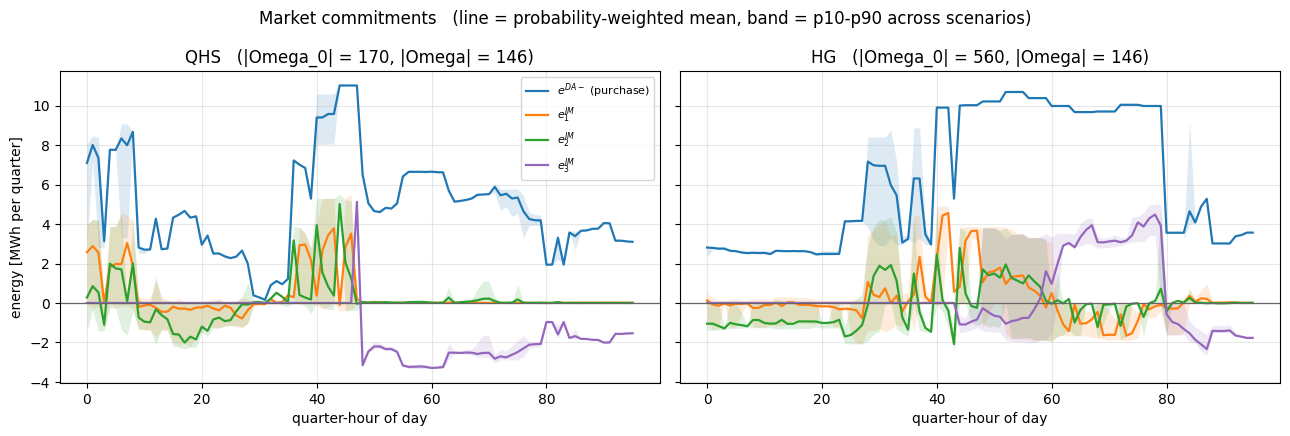

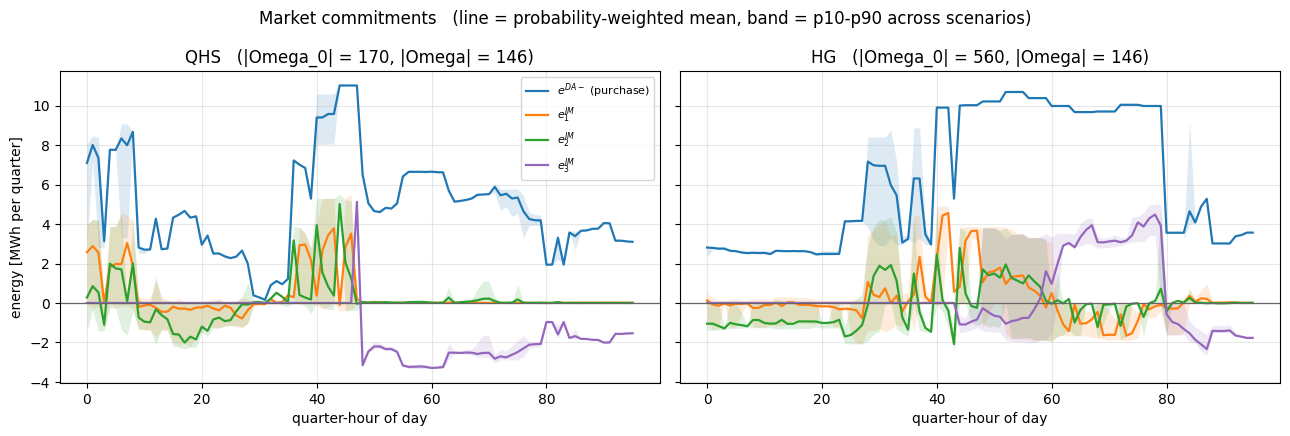

In [38]:
draw_profiles(
    [("eDA_m", "$e^{DA-}$ (purchase)", "#1f77b4"),
     ("eIM_1", "$e^{IM}_1$", "#ff7f0e"),
     ("eIM_2", "$e^{IM}_2$", "#2ca02c"),
     ("eIM_3", "$e^{IM}_3$", "#9467bd")],
    "Market commitments", "energy [MWh per quarter]", zero_line=True,
    name="dd_market_commitments")

### Figure `fig:reserve` — `qhs_f5_reserve_provision`, `hg_f5_reserve_provision`
> *Reserve provision at $\lvert\Omega\rvert = 146$.*

**Reproducible.** Total upward and downward reserve with the battery and flexible-demand
components that make them up. Both directions are reported as positive magnitudes, as the
model defines them.

saved  ..\..\TFM_ASP\figures\dd_reserve_provision.png


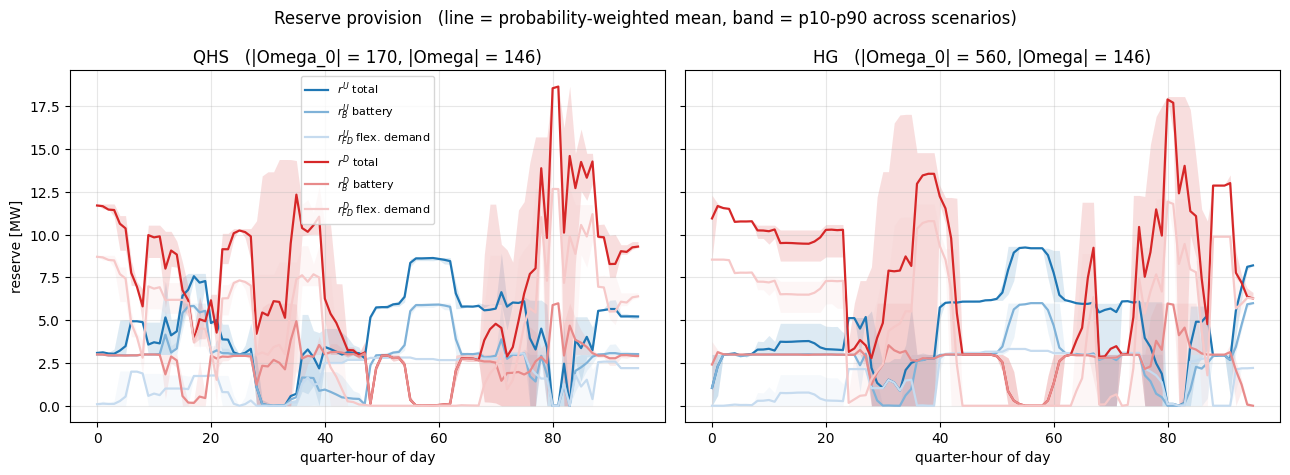

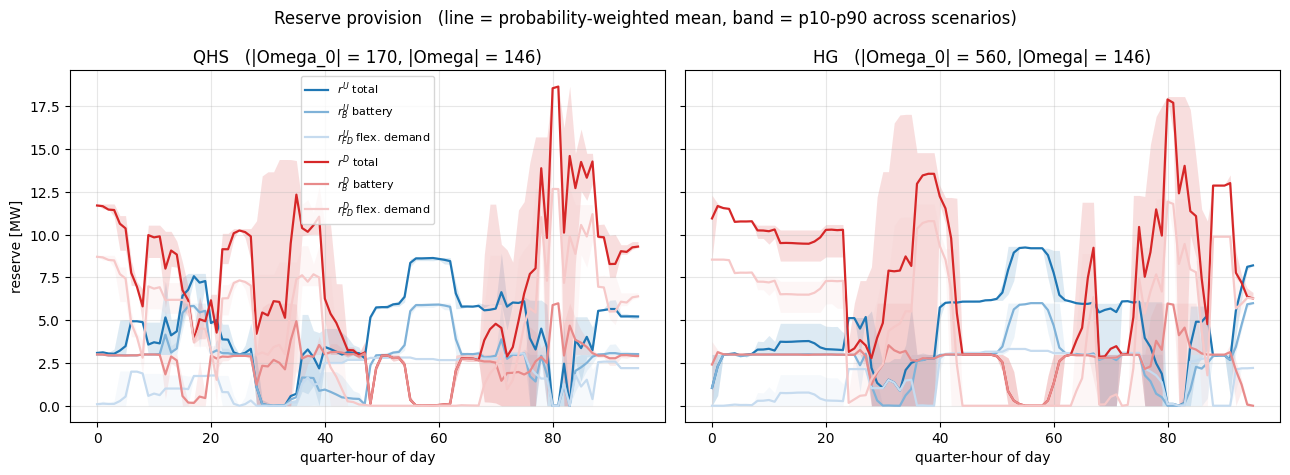

In [39]:
draw_profiles(
    [("rU", "$r^{U}$ total", "#1f77b4"), ("rU_B", "$r^{U}_{B}$ battery", "#7fb2d8"),
     ("rU_FD", "$r^{U}_{FD}$ flex. demand", "#c6dbef"),
     ("rD", "$r^{D}$ total", "#d62728"), ("rD_B", "$r^{D}_{B}$ battery", "#e88a8a"),
     ("rD_FD", "$r^{D}_{FD}$ flex. demand", "#f6c8c8")],
    "Reserve provision", "reserve [MW]", figsize=(13, 4.8),
    name="dd_reserve_provision")

### Figure `fig:bess` — `qhs_f2_bess_operation`, `hg_f2_bess_operation`
> *Battery operation at $\lvert\Omega\rvert = 146$.*

**Reproducible.** Charge and discharge rates, the signed net rate, and the state of charge.
**The net-rate sign is the point of this figure** — positive is net charging, negative net
discharging — so it is plotted signed with a zero reference, never as a magnitude.

saved  ..\..\TFM_ASP\figures\dd_bess_rates.png


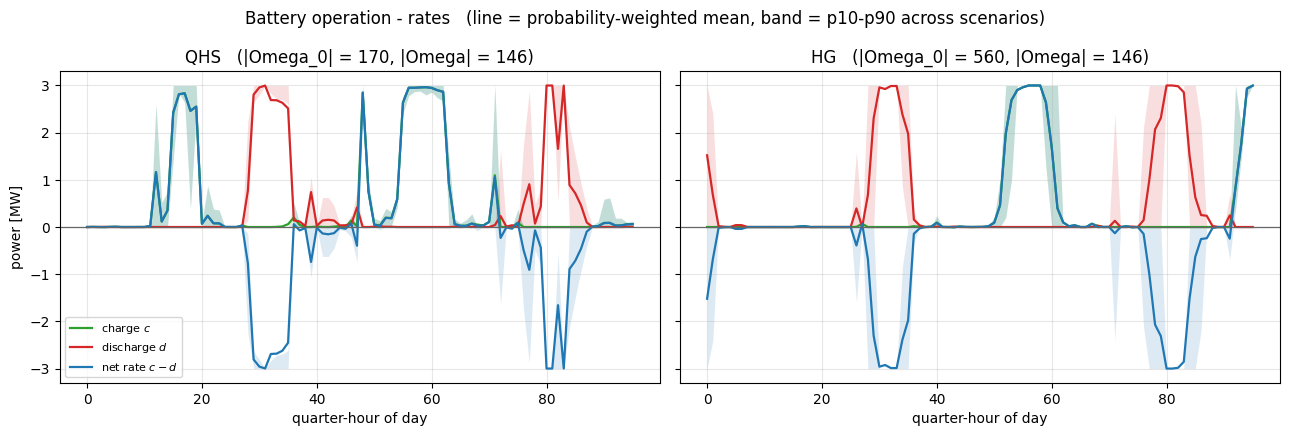

saved  ..\..\TFM_ASP\figures\dd_bess_soc.png


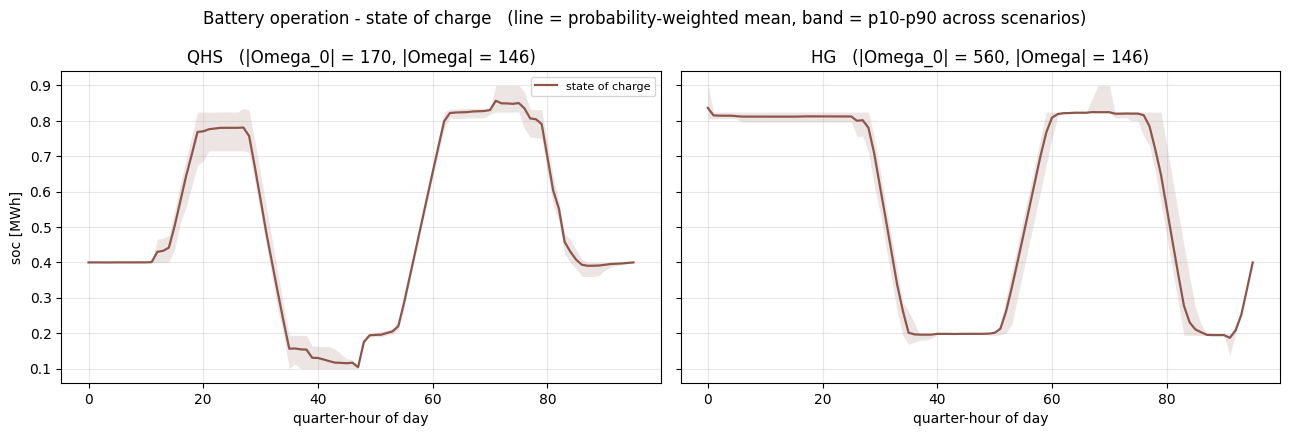

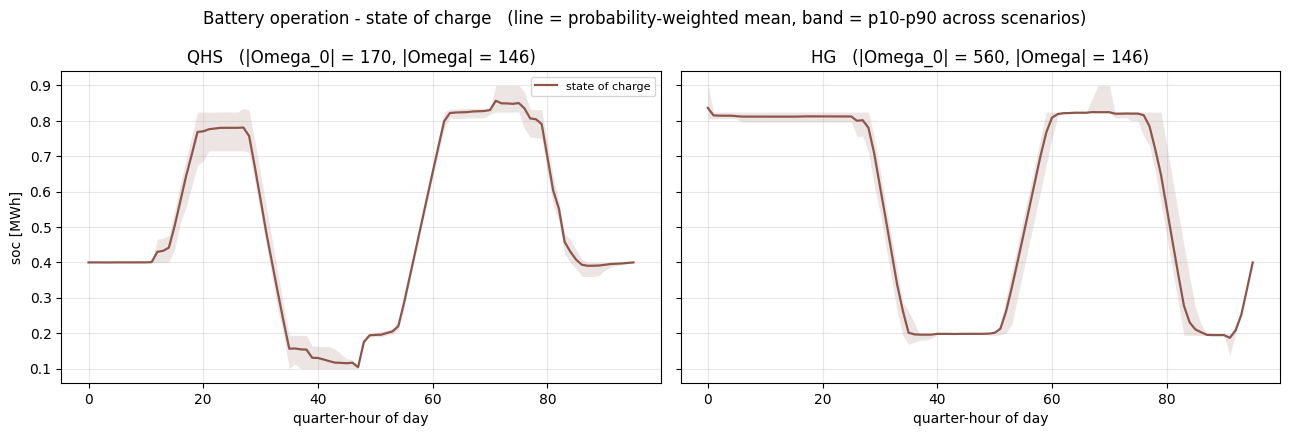

In [40]:
draw_profiles(
    [("cV", "charge $c$", "#2ca02c"), ("dV", "discharge $d$", "#d62728"),
     ("net_charge", "net rate $c - d$", "#1f77b4")],
    "Battery operation - rates", "power [MW]", sharey=True, zero_line=True,
    name="dd_bess_rates")

draw_profiles(
    [("soc", "state of charge", "#8c564b")],
    "Battery operation - state of charge", "soc [MWh]",
    name="dd_bess_soc")

### Figure `fig:renewables-soc` — `qhs_f1_renewables_soc`, `hg_f1_renewables_soc`
> *Renewables and state of charge at $\lvert\Omega\rvert = 146$.*

**Reproducible.** Wind and PV production against the state of charge. Note that renewable
production here is in the model's own per-unit-scaled MW, and — as flagged when rebuilding
Section 5.1 — the underlying scenario values include unphysical negatives.

saved  ..\..\TFM_ASP\figures\dd_renewables_soc.png


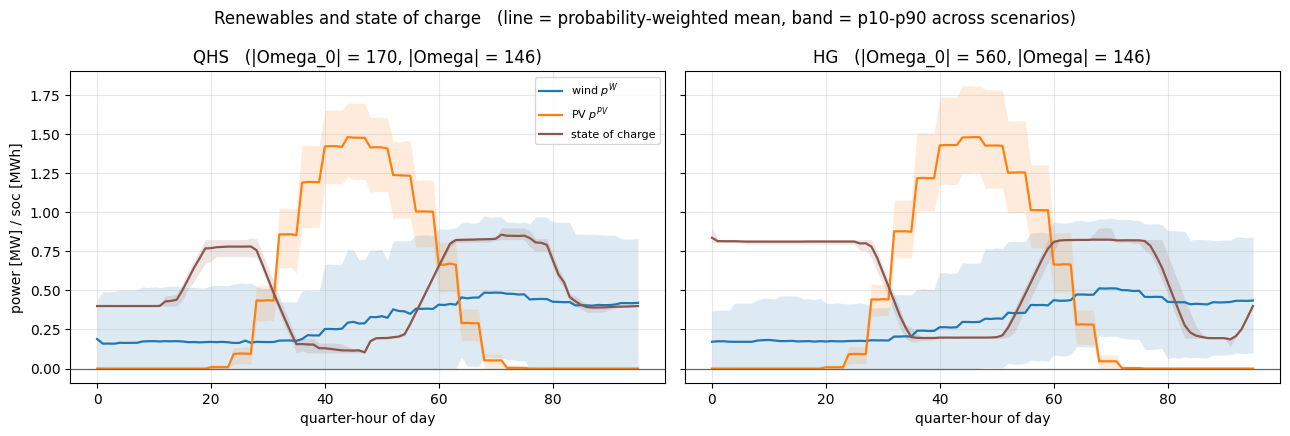

QHS  pW    min=  0.0000  negative cells  0.00%
QHS  pPV   min=  0.0000  negative cells  0.00%
HG   pW    min=  0.0000  negative cells  0.00%
HG   pPV   min=  0.0000  negative cells  0.00%


In [41]:
draw_profiles(
    [("pW", "wind $p^{W}$", "#1f77b4"), ("pPV", "PV $p^{PV}$", "#ff7f0e"),
     ("soc", "state of charge", "#8c564b")],
    "Renewables and state of charge", "power [MW] / soc [MWh]", zero_line=True,
    name="dd_renewables_soc")

# how much of the renewable input at this configuration is negative?
for lab in ORDER:
    for key, name in [("pW", "pW"), ("pPV", "pPV")]:
        v = deep[lab][key]
        print(f"{lab:4s} {name:5s} min={v.min():8.4f}  negative cells "
              f"{(v < 0).mean() * 100:5.2f}%")

### Figure `fig:flexdemand` — `qhs_f3_flexible_demand`, `hg_f3_flexible_demand`
> *Flexible demand at $\lvert\Omega\rvert = 146$.*

**Reproducible.** Central demand with the upward and downward displacement around it. Both
displacements are stored as positive magnitudes; the downward one is drawn negated so the
figure reads as displacement *around* the central profile, which is stated on the axis
rather than silently applied.

saved  ..\..\TFM_ASP\figures\dd_flexible_demand.png


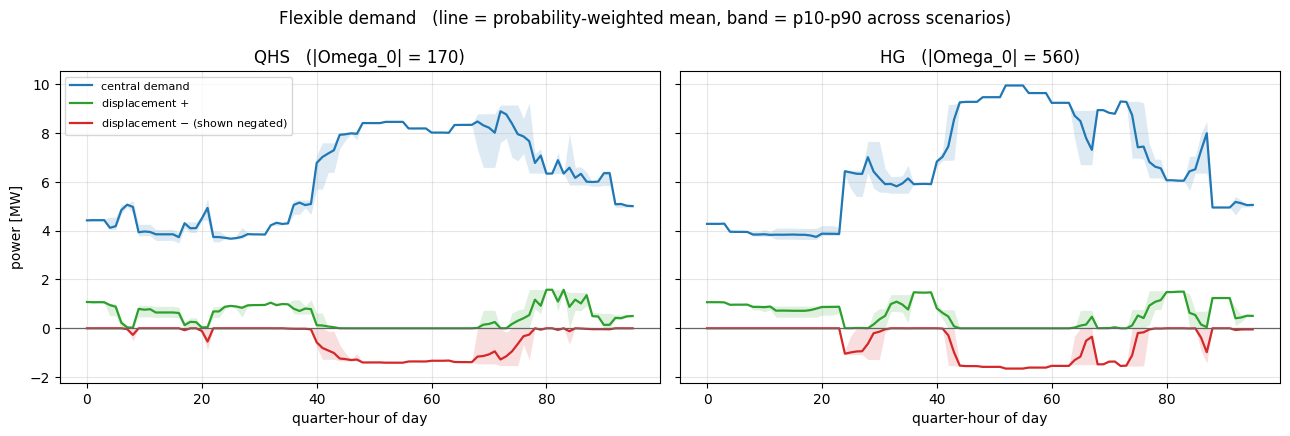

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, lab in zip(axes, ORDER):
    for key, name, colour, sign in [
            ("var_fd", "central demand", "#1f77b4", +1),
            ("var_afd_p", "displacement $+$", "#2ca02c", +1),
            # negated for display only: the stored series is a positive magnitude
            ("var_afd_m", "displacement $-$ (shown negated)", "#d62728", -1)]:
        p = profile(lab, key)
        ax.plot(QUARTER_HOURS, sign * p["mean"], lw=1.6, color=colour, label=name)
        ax.fill_between(QUARTER_HOURS, sign * p["low"], sign * p["high"],
                        color=colour, alpha=0.15, lw=0)
    ax.axhline(0, color="0.4", lw=0.9)
    ax.set_title(f"{lab}   (|Omega_0| = {DEEP_DIVE_POP[lab]})")
    ax.set_xlabel("quarter-hour of day")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("power [MW]")
axes[0].legend(fontsize=8)
fig.suptitle("Flexible demand   (line = probability-weighted mean, "
             f"band = p{BAND_LOW}-p{BAND_HIGH} across scenarios)")
fig.tight_layout()
save(fig, "dd_flexible_demand")
plt.show()

### Figure `fig:imbalance` — `hg_f6_imbalance_intraday`
> *Imbalance and intraday position under HG at $\lvert\Omega\rvert = 146$. The
> corresponding QHS panel is unavailable; see the note in the chapter.*

### 🔎 Reproducible for **both** formulations

The chapter renders this for HG only, because the QHS imbalance series could not be
identified. As established above, the QHS export does contain `pIB_p` and `pIB_m`, so the
QHS panel is drawn here too — the figure is no longer HG-only.

The intraday total is the derived `eIM_1 + eIM_2 + eIM_3`, signed: **negative is a net
sale**, and the sign is the whole content of the chapter's claim that the two formulations
take opposite net intraday positions.

saved  ..\..\TFM_ASP\figures\dd_imbalance_intraday.png


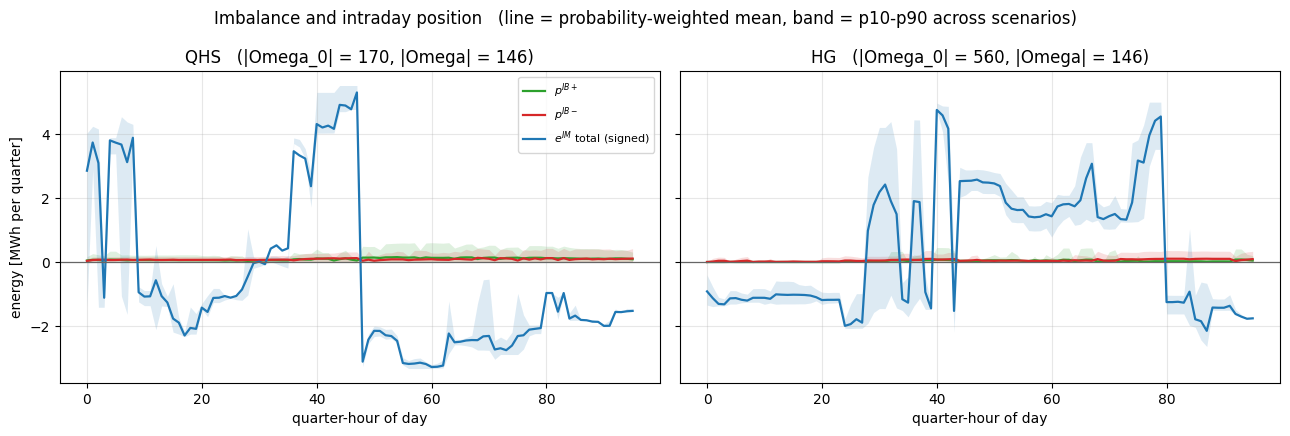

,mean e^IM total [MWh],sign,mean p^IB+ [MWh],mean p^IB- [MWh]
QHS,-0.57859,net sale,0.102146,0.08207
HG,0.447702,net purchase,0.037861,0.058038


In [43]:
draw_profiles(
    [("pIB_p", "$p^{IB+}$", "#2ca02c"), ("pIB_m", "$p^{IB-}$", "#d62728"),
     ("eIM_TOT", "$e^{IM}$ total (signed)", "#1f77b4")],
    "Imbalance and intraday position", "energy [MWh per quarter]", zero_line=True,
    name="dd_imbalance_intraday")

net_intraday = pd.DataFrame({
    lab: {"mean e^IM total [MWh]": deep[lab]["eIM_TOT"].mean(),
          "sign": "net sale" if deep[lab]["eIM_TOT"].mean() < 0 else "net purchase",
          "mean p^IB+ [MWh]": deep[lab]["pIB_p"].mean(),
          "mean p^IB- [MWh]": deep[lab]["pIB_m"].mean()}
    for lab in ORDER}).T
net_intraday

### Figure `fig:da-matched` — `batch_da_matched_comparison`
> *Probability-weighted mean day-ahead commitment profiles for both formulations at
> matched initial populations $\{50, 70, 100, 120, 150, 170\}$.*

**Reproducible.** Six runs per formulation, each contributing one probability-weighted
96-period profile. Unlike the figures above, this one spans several configurations, so it
loads `eDA_m` and its probabilities from each run directory in turn.

saved  ..\..\TFM_ASP\figures\batch_da_matched_comparison.png


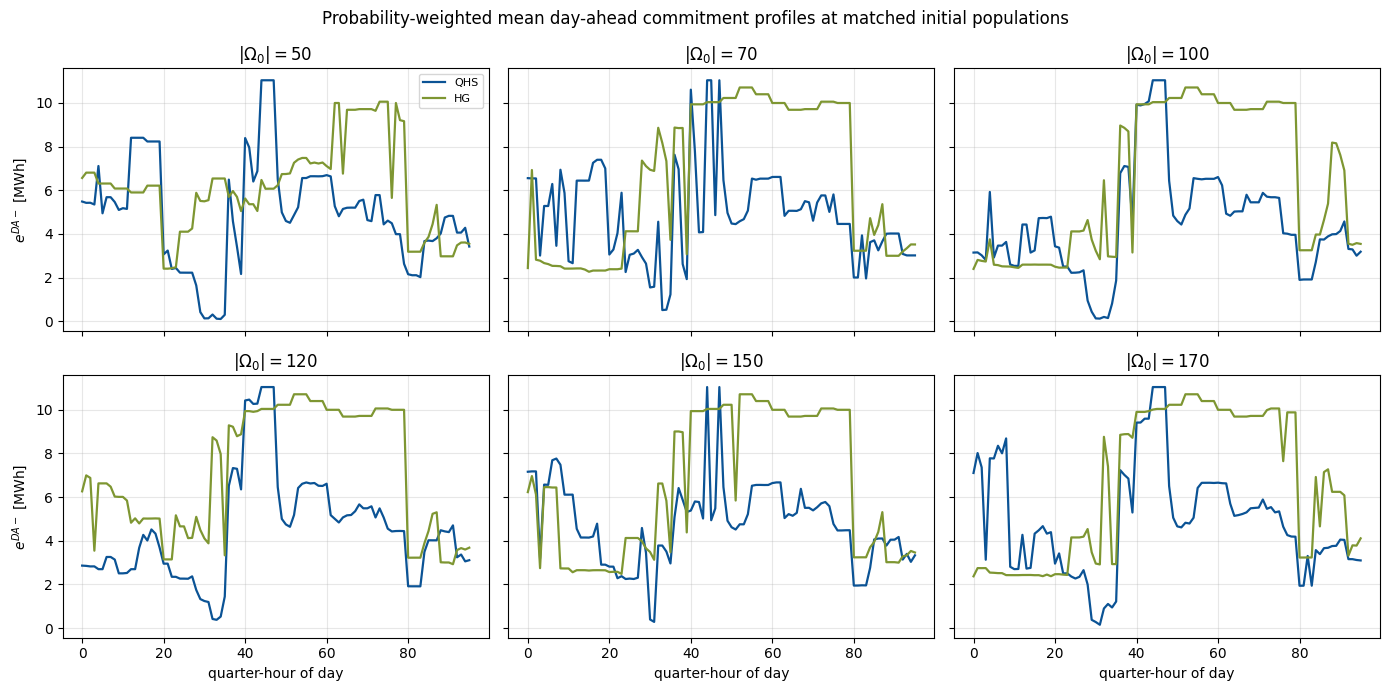

In [44]:
# --- computation -------------------------------------------------------------
DA_MATCHED_POPS = [50, 70, 100, 120, 150, 170]      # as named in the caption


def retained_at(lab, pop):
    """|Omega| for one run, from the batch CSV -- each export has that many rows."""
    row = ok[(ok.formulation == lab) & (ok.pop_initial == pop)]
    return int(row.iloc[0]["pop_retained"])


def da_profile(lab, pop):
    """Probability-weighted mean day-ahead purchase profile for one run."""
    prob, values, _ = load_var(lab, pop, "market/001/DA/eDA_m.txt", N_PERIODS,
                               n_scen=retained_at(lab, pop))
    return prob @ values


da_profiles = {(lab, pop): da_profile(lab, pop)
               for lab in ORDER for pop in DA_MATCHED_POPS}

# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, pop in zip(axes.ravel(), DA_MATCHED_POPS):
    for lab in ORDER:
        ax.plot(QUARTER_HOURS, da_profiles[(lab, pop)], lw=1.6,
                color=COLORS[lab], label=lab)
    ax.set_title(rf"$|\Omega_0| = {pop}$")
    ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel("quarter-hour of day")
for ax in axes[:, 0]:
    ax.set_ylabel("$e^{DA-}$ [MWh]")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Probability-weighted mean day-ahead commitment profiles at matched "
             "initial populations")
fig.tight_layout()
save(fig, "batch_da_matched_comparison")
plt.show()

### Figure `fig:da-absdiff` — `batch_da_mean_abs_diff`
> *Mean absolute difference between the two formulations' day-ahead commitment profiles,
> by initial population.*

**Reproducible.** For each $\lvert\Omega_0\rvert$ in the matched range, the mean over the
96 periods of $\lvert e^{DA-}_{\mathrm{QHS}}(t) - e^{DA-}_{\mathrm{HG}}(t) \rvert$, both
profiles probability-weighted. The absolute value here is the *defined metric*, not a
discarded sign.

range 2.34-3.69 MW, mean 2.82 MW
value at |Omega_0|=170: 2.91 MW (within the range spanned at 50: 2.42 and 60: 3.69)


saved  ..\..\TFM_ASP\figures\batch_da_mean_abs_diff.png


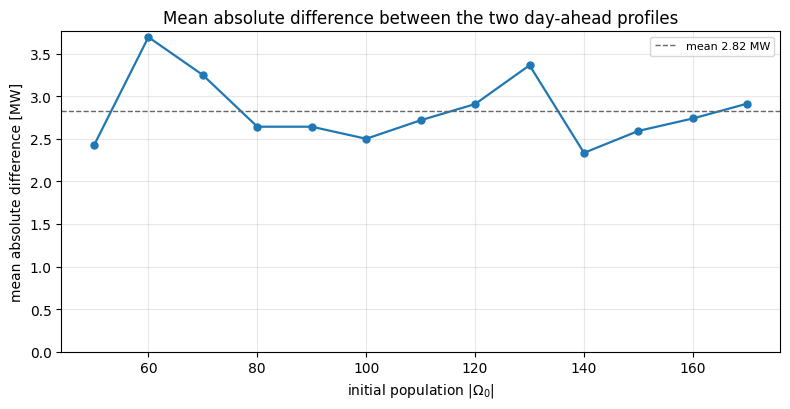

,mean |QHS - HG| [MW]
|Omega_0|,
50,2.423
60,3.695
70,3.249
80,2.643
90,2.642
100,2.501
110,2.718
120,2.908
130,3.364


In [45]:
# --- computation -------------------------------------------------------------
DA_DIFF_POPS = [p for p in range(MATCHED_POP_MIN, MATCHED_POP_MAX + 1, 10)]

da_all = {(lab, pop): da_profile(lab, pop) for lab in ORDER for pop in DA_DIFF_POPS}
da_abs_diff = pd.Series(
    {pop: np.abs(da_all[("QHS", pop)] - da_all[("HG", pop)]).mean() for pop in DA_DIFF_POPS},
    name="mean |QHS - HG| [MW]")
da_abs_diff.index.name = "|Omega_0|"

print(f"range {da_abs_diff.min():.2f}-{da_abs_diff.max():.2f} MW, "
      f"mean {da_abs_diff.mean():.2f} MW")
print(f"value at |Omega_0|=170: {da_abs_diff.loc[170]:.2f} MW "
      f"(within the range spanned at 50: {da_abs_diff.loc[50]:.2f} "
      f"and 60: {da_abs_diff.loc[60]:.2f})")

# --- plotting ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(da_abs_diff.index, da_abs_diff.values, marker="o", ms=5, lw=1.6, color="#1f77b4")
ax.axhline(da_abs_diff.mean(), color="0.4", ls="--", lw=1,
           label=f"mean {da_abs_diff.mean():.2f} MW")
ax.set_xlabel(r"initial population $|\Omega_0|$")
ax.set_ylabel("mean absolute difference [MW]")
ax.set_ylim(0, None)
ax.set_title("Mean absolute difference between the two day-ahead profiles")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
save(fig, "batch_da_mean_abs_diff")
plt.show()

da_abs_diff.round(3).to_frame()

---
## Coverage summary

| # | Item | Label | Status |
|---|---|---|---|
| — | Solver configuration | `tab:solver-config` | out of scope — defined in `methods.tex:434` |
| 1 | Model dimensions & solve time at matched count | `tab:dimensions-matched` | ✅ reproducible ⚠️ QHS times differ from chapter |
| 2 | Itemised reported quantities (time / iterations / memory / gap / feasibility) | prose list | ⚠️ partial — 3 of 5 available, memory & feasibility absent |
| 10b | Objective-component sign reconciliation | `tab:objective-components` | ⚠️ components do not sum to their Total as displayed |
| 3 | Solve time at equal initial population | `tab:time-matched-original` | ✅ reproducible ⚠️ QHS times differ |
| 4 | Solution time vs scenario count | `fig:batch-time` | ✅ reproducible ⚠️ QHS times differ |
| 5 | Model dimensions vs scenario count | `fig:batch-size` | ✅ reproducible |
| 6 | Reduction ratio & time per retained scenario | `fig:batch-efficiency` | ✅ reproducible ⚠️ QHS times differ |
| 7 | QHS convergence vs tree size | `tab:cliff` | ✅ reproducible (joins the scenario-tree CSV) |
| 8 | Tractability cliff | `fig:sg-cliff` | ✅ reproducible (joins the scenario-tree CSV) |
| 9 | Objective at equal initial population | `tab:objective-matched` | ✅ reproducible, exact |
| 10 | Objective components | `tab:objective-components` | ✅ reproducible, exact |
| 11 | Objective vs scenario count | `fig:batch-obj` | ✅ reproducible |
| 12 | Objective components vs scenario count | `fig:batch-obj-components` | ✅ reproducible |
| 13 | Decision-variable statistics at $\lvert\Omega\rvert=146$ | `tab:decisions-matched` | ✅ reproducible from the exports (QHS imbalance row now filled) |
| 14 | Per-scenario economic result by market | `tab:market-benefit` | ✅ reproducible (QHS IB row now filled) |
| 15 | Market commitments | `fig:commitments` | ✅ reproducible |
| 16 | Reserve provision | `fig:reserve` | ✅ reproducible |
| 17 | Battery operation | `fig:bess` | ✅ reproducible |
| 18 | Renewables & SOC | `fig:renewables-soc` | ✅ reproducible |
| 19 | Flexible demand | `fig:flexdemand` | ✅ reproducible |
| 20 | Imbalance & intraday | `fig:imbalance` | ✅ reproducible for **both** formulations — QHS defect resolved |
| 21 | Matched DA commitment profiles | `fig:da-matched` | ✅ reproducible |
| 22 | Mean absolute DA profile difference | `fig:da-absdiff` | ✅ reproducible |

**All 22 items render.** Items 1–12 come from the two batch CSVs (7–8 also joining the scenario-tree summary); items 13–22 from the
per-run solution exports under `results/`, described in the deep-dive preamble above.

Four things to carry out of this notebook:

1. **The QHS batch was re-run.** Objectives and dimensions are unchanged; every QHS solve
   time moved. The chapter's timing claims need restating against this CSV — or the
   original CSV needs recovering, if the published numbers are the ones to keep.
2. **`gurobi_nodes_explored` is 1 in all 68 converged runs.** The solver never branches:
   the 1% gap is met at the root. That makes the root-relaxation / branch-and-bound split
   the chapter flags as missing a degenerate question — all solve time is root time — and
   turns `gurobi_simplex_iterations` into the quantity that actually separates the two
   formulations.

3. **The `[DATA DEFECT]` on the QHS imbalance series is resolved.** The QHS export does
   contain `pIB_p`, `pIB_m`, `lPIB` and `lNIB`. The unidentified `{var_name}` variable the
   chapter describes — mean 0.0821, 59.34% zeros, max 1.1652 — is exactly $p^{IB-}$. Both
   QHS imbalance rows of `tab:decisions-matched`, the QHS `IB` row of `tab:market-benefit`,
   and the QHS panel of `fig:imbalance` are filled here.

4. **One published `% zero` does not reproduce.** `tab:decisions-matched` gives $r^{U}$ as
   0.00% zero under both formulations; the exports give 11.57% (QHS) and 12.78% (HG).
   Every other cell in that table matches.